## Importação de Bibliotecas

In [ ]:
import os
import pathlib
import numpy as np
import pandas as pd
import time
import cv2
import uuid
import random
import shutil

from PIL import Image, ImageEnhance
from skimage.util import random_noise

import tensorflow as tf
from tensorflow import keras
from keras import utils
from keras.utils import img_to_array, load_img

from keras.applications.vgg16 import VGG16, preprocess_input as preprocess_vgg16
from keras.applications.vgg19 import VGG19, preprocess_input as preprocess_vgg19
from keras.applications.resnet import ResNet50, preprocess_input as preprocess_resnet
from keras.applications.resnet_v2 import ResNet50V2, preprocess_input as preprocess_resnetv2
from keras.applications.inception_resnet_v2 import InceptionResNetV2, preprocess_input as preprocess_inceptionresnetv2
from keras.applications.inception_v3 import InceptionV3, preprocess_input as preprocess_inceptionv3
from keras.applications.convnext import ConvNeXtSmall  # Sem preprocessamento manual
from keras.applications.efficientnet_v2 import EfficientNetV2B0, EfficientNetV2B3  # Sem preprocessamento manual
from keras.applications import MobileNetV3Small  # Sem preprocessamento manual

from keras.utils import load_img, img_to_array
from keras import backend as K
from keras import layers

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler

from collections import Counter

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score, matthews_corrcoef, classification_report, cohen_kappa_score, make_scorer

import matplotlib.pyplot as plt
import seaborn as sns

import gc

import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("=" * 60)
print("VERIFICAÇÃO DE GPU NO NOTEBOOK")
print("=" * 60)

# Verificar GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs detectadas: {len(gpus)}")
if gpus:
    print(f"✅ GPU disponível: {gpus[0]}")
else:
    print("❌ Nenhuma GPU detectada")

print("=" * 60)

VERIFICAÇÃO DE GPU NO NOTEBOOK
GPUs detectadas: 1
✅ GPU disponível: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
import os

#BASE_PROJECT = '/mnt/c/Users/laris/Documents/EngineLab/Caries' # Caminho para o projeto no WSL
BASE_PROJECT = r'C:\Users\laris\Documents\EngineLab\Caries\Pipeline' # Caminho para o projeto no windows
DATASET_DIR = os.path.join(BASE_PROJECT, 'Dataset')
FEATURES_DIR = os.path.join(BASE_PROJECT, 'features')
METRICS_DIR = os.path.join(BASE_PROJECT, 'Metricas')

## Carregando Imagens

In [ ]:
base_dir = DATASET_DIR
data_dir = pathlib.Path(base_dir)

# Lista das pastas de classe
class_paths = sorted([x for x in data_dir.iterdir() if x.is_dir()])

for classe in class_paths:
    print(classe.name)

Hígidos
Iniciais
Severas


In [ ]:
def get_class_images(class_paths, i):
    exts = ['*.jpg', '*.JPG', '*.png', '*.PNG']

    image_paths = []
    for ext in exts:
        image_paths.extend(class_paths[i].glob(ext))

    # Remove as duplicatas criadas pela busca case-insensitive do SO
    image_paths = list(set(image_paths))

    class_name = class_paths[i].name
    return class_name, image_paths

for i in range(len(class_paths)):
  class_name, images = get_class_images(class_paths, i)
  print(f"Classe [{i}] - {class_name} - Total de imagens: {len(images)}")

Classe [0] - Hígidos - Total de imagens: 102
Classe [1] - Iniciais - Total de imagens: 80
Classe [2] - Severas - Total de imagens: 174


In [ ]:
image_paths = []
labels = []

class_names = [p.name for p in class_paths]
print("Classes:", class_names)

for label, class_path in enumerate(class_paths):
    class_name, images = get_class_images(class_paths, label)

    image_paths.extend(images)
    labels.extend([label] * len(images))

Classes: ['Hígidos', 'Iniciais', 'Severas']


In [ ]:
from collections import Counter
Counter(labels)

Counter({2: 174, 0: 102, 1: 80})

## Análise dataset

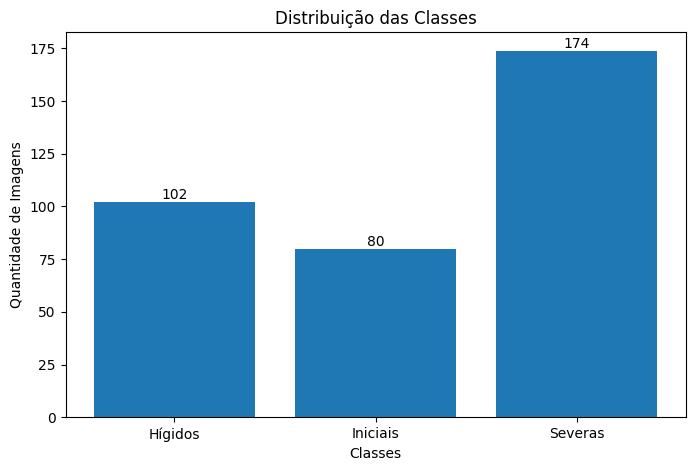

In [ ]:
classes = []
quantidades = []

for i in range(len(class_paths)):
    class_name, images = get_class_images(class_paths, i)
    classes.append(class_name)
    quantidades.append(len(images))

plt.figure(figsize=(8, 5))
plt.bar(classes, quantidades)

plt.title('Distribuição das Classes')
plt.xlabel('Classes')
plt.ylabel('Quantidade de Imagens')

# Mostra os valores em cima das barras
for i, value in enumerate(quantidades):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

## Plotando imagens

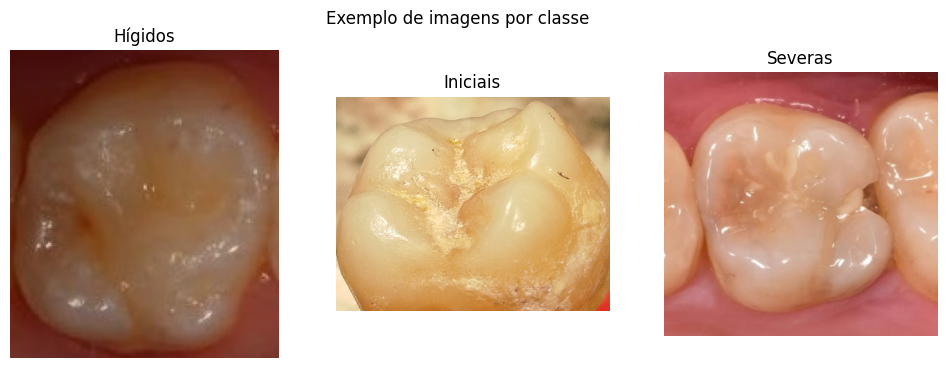

In [ ]:
plt.figure(figsize=(12, 4))

for i, class_path in enumerate(class_paths):
    class_name, images = get_class_images(class_paths, i)

    # Verifica se a classe não está vazia para evitar erros de índice
    if len(images) > 0:
        # Lê o arquivo via NumPy para evitar o bug de acentos do cv2.imread
        img_array = np.fromfile(str(images[0]), np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(class_paths), i + 1)
        plt.title(class_name)
        plt.imshow(img_rgb)
        plt.axis('off')

plt.suptitle('Exemplo de imagens por classe')
plt.show()

## Data Augmentation

In [ ]:
def apply_manual_augmentations(img, num_aug=2):
    augmented_images = []

    for _ in range(num_aug):
        try:
            aug_img = img.copy()

            # 1. ESPELHAMENTO
            if random.random() < 0.5:
                aug_img = aug_img.transpose(Image.FLIP_LEFT_RIGHT)

            if random.random() < 0.5:
                aug_img = aug_img.transpose(Image.FLIP_TOP_BOTTOM)

            # 2. TRANSFORMAÇÃO GEOMÉTRICA
            geometric = random.choice(['rotate', 'zoom', 'none'])

            if geometric == 'rotate':
                # Rotação: Reduzi para +/- 15 graus
                angle = random.uniform(-20, 20)

                # Rotacionar e dar zoom para evitar muitos cantos pretos
                aug_img = aug_img.rotate(angle, resample=Image.BICUBIC, expand=False)

                # Pequeno crop central para remover possíveis bordas pretas da rotação
                w, h = aug_img.size
                crop_margin = 0.05 # 5% de margem
                aug_img = aug_img.crop((
                    w*crop_margin, h*crop_margin,
                    w*(1-crop_margin), h*(1-crop_margin)
                ))
                aug_img = aug_img.resize((w, h), Image.LANCZOS) # Volta ao tamanho original

            elif geometric == 'zoom':
                # Zoom (Crop central)
                zoom_factor = random.uniform(1.05, 1.15) # Zoom leve
                w, h = aug_img.size
                new_w, new_h = int(w * zoom_factor), int(h * zoom_factor)

                # Resize para simular estar "mais perto"
                img_zoomed = aug_img.resize((new_w, new_h), Image.LANCZOS)

                # Crop central exato para voltar ao tamanho original
                left = (new_w - w) // 2
                top = (new_h - h) // 2
                aug_img = img_zoomed.crop((left, top, left + w, top + h))

            # 3. TRANSFORMAÇÃO FOTOMÉTRICA
            if random.random() < 0.8:
                photometric = random.choice(['brightness', 'contrast', 'sharpness'])

                if photometric == 'brightness':
                    enhancer = ImageEnhance.Brightness(aug_img)
                    # Intervalo mais conservador (0.9 a 1.1)
                    aug_img = enhancer.enhance(random.uniform(0.9, 1.15))

                elif photometric == 'contrast':
                    enhancer = ImageEnhance.Contrast(aug_img)
                    aug_img = enhancer.enhance(random.uniform(0.9, 1.15))

                elif photometric == 'sharpness':
                    # Sharpness ajuda a destacar bordas de cáries
                    enhancer = ImageEnhance.Sharpness(aug_img)
                    aug_img = enhancer.enhance(random.uniform(1.0, 1.5))

            augmented_images.append(aug_img)

        except Exception as e:
            print(f"Erro na augmentação: {str(e)}")
            continue

    return augmented_images

In [ ]:
def augment_images_manually(image_paths, num_aug=3, repeat=0):
    augmented_paths = []

    for img_path in image_paths:
        try:
            aug_dir = os.path.join(os.path.dirname(img_path), f'data_aug_rep{repeat}')
            os.makedirs(aug_dir, exist_ok=True)

            original_name = os.path.splitext(os.path.basename(img_path))[0]

            # Sempre gera novas augmentações para cada repeat
            img = Image.open(img_path).convert('RGB')
            augmented_imgs = apply_manual_augmentations(img, num_aug=num_aug)

            for i, aug_img in enumerate(augmented_imgs):
                # Nome do arquivo baseado no original
                aug_path = os.path.join(aug_dir, f"{original_name}_aug_{i}.jpg")

                # Verifica se o arquivo já existe
                if not os.path.exists(aug_path):
                    aug_img.save(aug_path)

                augmented_paths.append(aug_path)

        except Exception as e:
            print(f"[ERRO] {img_path}: {str(e)}")
            continue
    return augmented_paths

## Carrega as imagens origiais

In [ ]:
# Função para carregar apenas imagens originais (sem augmentação)
def load_original_images(base_path, classes):
    all_images = []
    all_labels = []

    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(base_path, class_name)

        images = []
        for root, _, files in os.walk(class_dir):
            if 'data_aug' in root:  # Ignora diretório de augmentação
                continue
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    images.append(os.path.join(root, f))

        all_images.extend(images)
        all_labels.extend([class_idx] * len(images))

    return all_images, all_labels

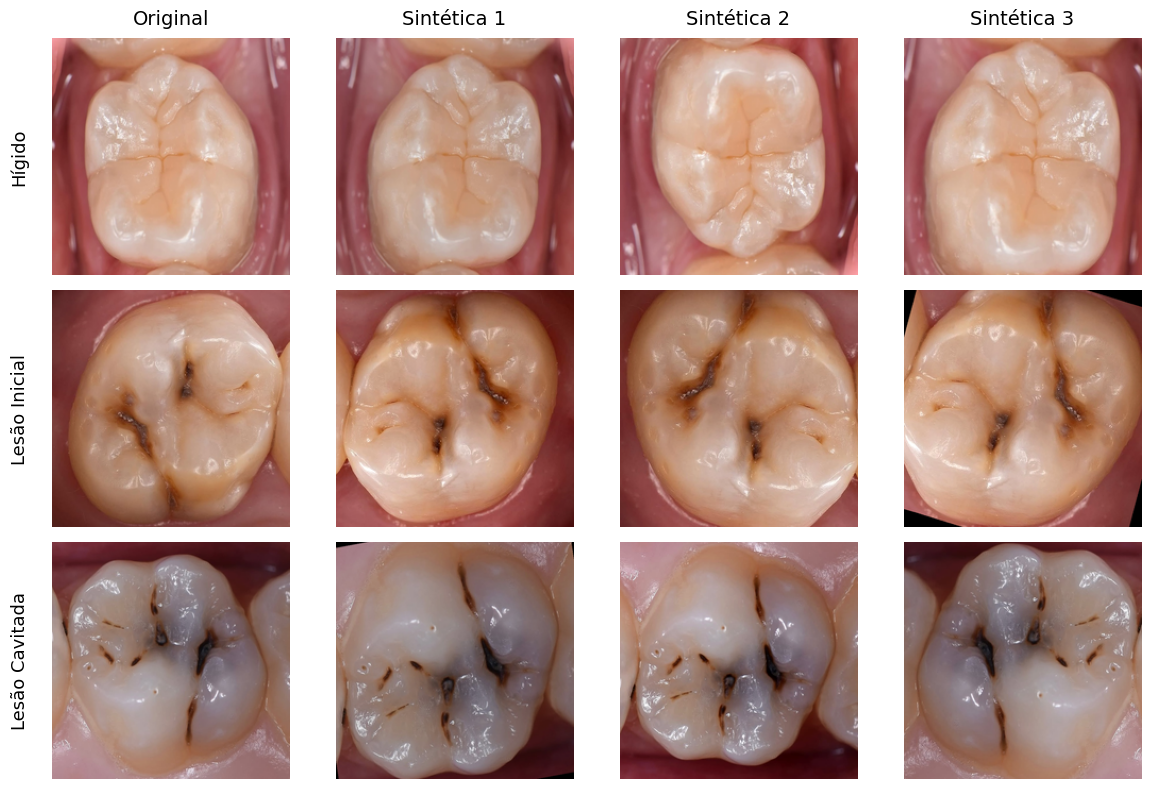

Figura salva em: resultado_augmentation_padronizado.png


In [ ]:
def generate_custom_augmentation_figure(
    base_dataset_dir,
    specific_files,
    classes_map,
    output_file="figura_augmentations.png",
    display_size=(224, 224) # Tamanho padrão para visualização
):
    """
    Gera figura com imagens específicas.

    specific_files: Dicionário {classe_idx: "nome_do_arquivo.jpg"}
    """

    fig, axes = plt.subplots(3, 4, figsize=(12, 8))
    plt.subplots_adjust(wspace=0.1, hspace=0.1)

    # Mapeamento de pastas
    folder_map = {
        0: 'Hígidos',
        1: 'Iniciais',
        2: 'Severas'
    }

    for i, (cls_idx, filename) in enumerate(specific_files.items()):

        # Constrói o caminho completo
        folder_name = folder_map.get(cls_idx, str(cls_idx))
        img_path = os.path.join(base_dataset_dir, folder_name, filename)

        try:
            # Carregar e redimensionar para padronização visual
            original_pil = Image.open(img_path).convert('RGB')

            # Gera augmentations
            augmented_list = apply_manual_augmentations(original_pil, num_aug=3)

            # Lista para plotar (Original + 3 Sintéticas)
            imgs_to_plot = [original_pil] + augmented_list[:3]

            # PLOTAGEM
            for j, img in enumerate(imgs_to_plot):
                ax = axes[i, j]

                img_display = img.resize(display_size, Image.LANCZOS)

                ax.imshow(img_display)
                ax.axis('off')

                # Títulos (Topo)
                if i == 0:
                    titles = ["Original", "Sintética 1", "Sintética 2", "Sintética 3"]
                    ax.set_title(titles[j], fontsize=14, pad=10)

            # Rótulo Lateral (Nome da Classe)
            class_name = classes_map[cls_idx]
            axes[i, 0].text(-0.1, 0.5, class_name,
                           transform=axes[i, 0].transAxes,
                           va='center', ha='right',
                           fontsize=13, rotation=90)

        except Exception as e:
            print(f"Erro ao carregar {img_path}: {e}")
            axes[i, 0].text(0.5, 0.5, "Arquivo não encontrado", ha='center')

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Figura salva em: {output_file}")

arquivos_escolhidos = {
    0: "hígido67.jpg",   # Exemplo Hígido
    1: "0024.jpg",   # Exemplo Inicial
    2: "0071.jpg"
}

nomes_classes = {
    0: 'Hígido',
    1: 'Lesão Inicial',
    2: 'Lesão Cavitada'
}

generate_custom_augmentation_figure(
    base_dataset_dir=DATASET_DIR,
    specific_files=arquivos_escolhidos,
    classes_map=nomes_classes,
    output_file="resultado_augmentation_padronizado.png"
)

## Pré-processamento: carrega e converte imagens em arrays NumPy

In [ ]:
def process_images(img_paths, target_size=(300, 300)):
    X = []
    for path in img_paths:
      try:
          if not os.path.exists(path):
              print(f"Aviso: Arquivo não encontrado {path}")
              continue
          img = load_img(path, target_size=target_size)
          x = img_to_array(img).astype(np.float32)
          X.append(x)

      except Exception as e:
          print(f"Erro ao processar {path}: {str(e)}")
          continue

    return np.array(X)  # Shape: (n_samples, 300, 300, 3)

## Extraindo características

### CNNs para extração de features

In [ ]:
def preprocessar_imagens(X, model_id):
    """
    Aplica o pré-processamento correto para cada modelo.

    Parâmetros:
      - X: imagens no formato float32 e escala [0, 255]
      - model_id: ID do modelo (de 0 a 9)

    Retorna:
      - X preprocessado de acordo com o modelo
    """
    if model_id == 0:
        return preprocess_vgg16(X)
    elif model_id == 1:
        return preprocess_vgg19(X)
    elif model_id == 2:
        return preprocess_resnet(X)
    elif model_id == 3:
        return preprocess_resnetv2(X)
    elif model_id == 4:
        return preprocess_inceptionresnetv2(X)
    elif model_id == 5:
        return preprocess_inceptionv3(X)
    elif model_id in [6, 7, 8, 9]:
        return X  # Esses modelos lidam com o pré-processamento internamente
    else:
        raise ValueError("ID de modelo inválido.")

In [ ]:
# Extrai as Features com as CNNs
def extract_features(model, X, y, isExtractorOnly, file_prefix, force_recompute=False, batch_size=16):
    """
    Extrai as features usando o modelo pré-treinado (por exemplo, ResNet50, VGG16, InceptionV3). --- no momento estou usando EfficientNetV2B0

    Parâmetros:
        - model: inteiro que indica qual modelo usar (0: VGG16, 1: InceptionV3, 2: ResNet50)
        - X: array com as imagens de entrada
        - y: array com os rótulos correspondentes
        - isExtractorOnly: se True, congela as camadas do modelo base
        - file_prefix: string para identificar o conjunto (ex: 'train' ou 'test')

    Retorna:
        - ExtractedFeatures: array com as features extraídas
        - base_model: o modelo base usado para extração
        - extractor_name: nome do extrator utilizado (ex: 'ResNet50')
        - y: array de rótulos carregado ou salvo (para garantir compatibilidade)
    """
    # Configurações específicas por modelo
    MODEL_CONFIG = {
        0: {'class': VGG16, 'shape': (224,224,3)},
        1: {'class': VGG19, 'shape': (224,224,3)},
        2: {'class': ResNet50, 'shape': (224,224,3)},
        3: {'class': ResNet50V2, 'shape': (224,224,3)},
        4: {'class': InceptionResNetV2, 'shape': (299,299,3)},
        5: {'class': InceptionV3, 'shape': (299,299,3)},
        6: {'class': MobileNetV3Small, 'shape': (224,224,3)},
        7: {'class': ConvNeXtSmall, 'shape': (224,224,3)},
        8: {'class': EfficientNetV2B3, 'shape': (300,300,3)},
        9: {'class': EfficientNetV2B0, 'shape': (224,224,3)}
    }

    config = MODEL_CONFIG[model]

    base_model = config['class'](
        include_top=False,
        weights='imagenet',
        input_shape=config['shape'],
        pooling='max'
    )

    if isExtractorOnly:
        base_model.trainable = False

    # ID único por execução
    extractor = config['class'].__name__
    unique_id = f"{file_prefix}_{extractor}"

    path_features = os.path.join(
        FEATURES_DIR,
        f'{unique_id}_features.npy'
    )

    path_labels = os.path.join(
        FEATURES_DIR,
        f'{unique_id}_labels.npy'
    )

    if os.path.exists(path_features):
        print(f"Carregando features existentes: {path_features}")
        return np.load(path_features), base_model, extractor, np.load(path_labels), 0.0

    # Adiciona redimensionamento dinâmico se necessário
    if not force_recompute and X.shape[1:3] != config['shape'][:2]:
        print(f"Aviso: Redimensionando imagens de {X.shape[1:3]} para {config['shape'][:2]}")
        X_resized = tf.image.resize(X, config['shape'][:2])
    else:
        X_resized = X

    try:
        # Verificação dimensional
        if X_resized.shape[1:3] != config['shape'][:2]:
            raise ValueError(f"Dimensões da imagem {X_resized.shape[1:3]} não correspondem ao esperado {config['shape'][:2]}")

        # if os.path.exists(path_features):
        #     os.remove(path_features)  # Força nova extração

        print(f"Extraindo features de {file_prefix} com {config['class'].__name__}...")
        start = time.time()

        # Processa em lotes para evitar OOM
        features_list = []
        n_batches = int(np.ceil(len(X) / batch_size))

        for i in range(n_batches):
            batch_start = i * batch_size
            batch_end = min((i + 1) * batch_size, len(X))

            batch_X = X_resized[batch_start:batch_end]

            batch_features = base_model.predict(batch_X, verbose=0)
            features_list.append(batch_features)

            # Progresso
            if (i + 1) % max(1, n_batches // 10) == 0 or i == n_batches - 1:
                print(f"  Lote {i+1}/{n_batches} processado ({batch_end} imagens)")

        # Concatena todos os lotes
        features = np.vstack(features_list)

        end = time.time()

        extraction_time = end - start
        print(f"Tempo de extração das features: {extraction_time:.2f} segundos")
        print(f"Tamanho das features extraídas: {features.shape}")

        np.save(path_features, features)
        np.save(path_labels, y)

        time_per_image_cnn = extraction_time / len(X)
        print(f"Latência CNN por imagem: {time_per_image_cnn*1000:.2f} ms")

        return features, base_model, config['class'].__name__, y, extraction_time, time_per_image_cnn

    finally:
        # Limpeza garantida
        tf.keras.backend.clear_session()
        del base_model

### Salva as features em um arquivo CSV

In [ ]:
def salvar_features_em_csv(features, labels, prefix='train', extractor='EfficientNetV2B0'):
    """
    Salva as features extraídas e seus rótulos em um arquivo CSV para análise posterior.

    Parâmetros:
        features (np.array): matriz de features com shape (n_amostras, n_features)
        labels (np.array): vetor de rótulos com shape (n_amostras,)
        prefix (str): nome do conjunto (ex: 'train' ou 'test')
        extractor (str): nome do extrator (ex: 'EfficientNetV2B0')
    """
    # Cria DataFrame com as features
    df = pd.DataFrame(features, columns=[f'feature_{i}' for i in range(features.shape[1])])

    # Adiciona os rótulos ao DataFrame
    df['label'] = labels

    # Define caminho e nome do arquivo
    caminho = os.path.join(
        FEATURES_DIR,
        f'{prefix}_{extractor}_features.csv'
    )

    # Salva como CSV
    df.to_csv(caminho, index=False)
    print(f'Features salvas em: {caminho}')

## Cria arquivos de métricas

In [ ]:
def save_metrics(
    metrics,
    final_metrics,
    stds,
    times,
    model_name="Modelo",
    extractor_name="extrator",
    base_folder="resultados",
    repeat=None
):
    csv_file = os.path.join(base_folder, f"{extractor_name}_metrics.csv")
    n_folds = len(metrics['val_acc'])
    qwk_value = final_metrics.get('qwk', None)

    data = {
        'Repetição': repeat,
        'Modelo': model_name,

        # ---- TESTE ----
        'Acurácia Teste (%)': final_metrics['acc'] * 100,
        'Kappa Quadrático (QWK)': qwk_value,
        'F1 Macro Teste (%)': final_metrics['f1_macro'] * 100,
        'F1 Weighted Teste (%)': final_metrics['f1_weighted'] * 100,
        'Recall Macro Teste (%)': final_metrics['recall_macro'] * 100,
        'Precisão Macro Teste (%)': final_metrics['precision_macro'] * 100,
        'MCC Teste': final_metrics['mcc'],

        'Matriz de Confusão (Teste)': [final_metrics['conf_matrix']],
        'Classification Report (Teste)': [final_metrics['classification_report']],

        # ---- TEMPOS ----
        'Tempo de Treinamento (s)': np.mean(times['train']),
        'Tempo de Teste (s)': np.mean(times['test']),
        'Latência por Imagem (ms)': times.get('latency_ms', 0),

        # ---- HISTÓRICO ----
        'Acurácias de Validação': [metrics['val_acc']],
        'F1 Macro Validação': [metrics['val_f1_macro']],
        'Recall Macro Validação': [metrics['val_recall_macro']],
        'Precisão Macro Validação': [metrics['val_precision_macro']],
        'Matrizes de Confusão (Validação)': [metrics['val_conf_matrices']],

        'Tempo Extração Features (s)': final_metrics['tempo_extracao'],
    }

    # ---- LOSS (somente se existir) ----
    if 'train_loss' in metrics and 'val_loss' in metrics:
        data['Loss Treino'] = [metrics['train_loss']]
        data['Loss Validação'] = [metrics['val_loss']]
    else:
        data['Loss Treino'] = [None]
        data['Loss Validação'] = [None]

    new_df = pd.DataFrame([data])
    os.makedirs(os.path.dirname(csv_file), exist_ok=True)

    if os.path.exists(csv_file):
        try:
            existing_df = pd.read_csv(csv_file)
            updated_df = pd.concat([existing_df, new_df], ignore_index=True)
        except Exception as e:
            print(f"Erro ao ler CSV existente. Substituindo. Erro: {e}")
            updated_df = new_df
    else:
        updated_df = new_df

    updated_df.to_csv(csv_file, index=False)
    print(f"Métricas salvas em: {csv_file}")

In [ ]:
def calcular_medias_csv(pasta_csv):
    arquivos = [f for f in os.listdir(pasta_csv) if f.endswith('_metrics.csv')]

    if not arquivos:
        print("Nenhum arquivo de métricas encontrado.")
        return

    for nome_arquivo in arquivos:
        caminho_csv = os.path.join(pasta_csv, nome_arquivo)
        nome_resumo = nome_arquivo.replace('_metrics.csv', '_medias.csv')
        caminho_resumo = os.path.join(pasta_csv, nome_resumo)

        print(f"\nProcessando: {nome_arquivo}")

        try:
            df = pd.read_csv(caminho_csv)
        except Exception as e:
            print(f"Erro ao ler {nome_arquivo}: {e}")
            continue

        if 'Modelo' not in df.columns:
            print(f"{nome_arquivo} não possui coluna 'Modelo'. Pulando.")
            continue

        # Remove médias antigas
        df = df[df['Repetição'] != 'MÉDIA']

        modelos = df['Modelo'].unique()

        colunas_metricas = [
            'Acurácia Teste (%)',
            'Kappa Quadrático (QWK)',
            'F1 Macro Teste (%)',
            'F1 Weighted Teste (%)',
            'Recall Macro Teste (%)',
            'Precisão Macro Teste (%)',
            'MCC Teste',
            'Tempo Extração Features (s)',
            'Tempo de Treinamento (s)',
            'Tempo de Teste (s)',
            'Latência por Imagem (ms)'
        ]

        linhas_resumo = []

        for modelo in modelos:
            df_modelo = df[df['Modelo'] == modelo]

            medias = df_modelo[colunas_metricas].mean()
            desvios = df_modelo[colunas_metricas].std()

            linha = {
                'Modelo': modelo,
                'Repetição': 'MÉDIA'
            }

            # Médias
            for col in colunas_metricas:
                linha[col] = medias.get(col, None)

            # Desvios padrão
            linha['Desvio Acurácia (%)'] = desvios.get('Acurácia Teste (%)', None)
            linha['Desvio Kappa Quadrático (QWK)'] = desvios.get('Kappa Quadrático (QWK)', None)
            linha['Desvio F1 Macro (%)'] = desvios.get('F1 Macro Teste (%)', None)
            linha['Desvio F1 Weighted (%)'] = desvios.get('F1 Weighted Teste (%)', None)
            linha['Desvio Recall Macro (%)'] = desvios.get('Recall Macro Teste (%)', None)
            linha['Desvio Precisão Macro (%)'] = desvios.get('Precisão Macro Teste (%)', None)
            linha['Desvio MCC'] = desvios.get('MCC Teste', None)

            linhas_resumo.append(linha)

        df_summary = pd.DataFrame(linhas_resumo)
        df_summary.to_csv(caminho_resumo, index=False)

        print(f"Resumo salvo em: {nome_resumo}")

## Parâmetros pro GridSearch

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone

class OrdinalClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator=None):
        self.estimator = estimator
        self.clfs = {}
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.sort(np.unique(y))
        if len(self.classes_) <= 2:
            raise ValueError("OrdinalClassifier precisa de pelo menos 3 classes.")

        # Treina N-1 classificadores binários
        # Para 3 classes: Clf0 (y > 0?) e Clf1 (y > 1?)
        for i in range(len(self.classes_) - 1):
            binary_y = (y > self.classes_[i]).astype(int)
            clf = clone(self.estimator)
            clf.fit(X, binary_y)
            self.clfs[i] = clf
        return self

    def predict_proba(self, X):
        # Obtém probabilidades P(y > class_i)
        probs = np.column_stack([self.clfs[i].predict_proba(X)[:, 1] for i in self.clfs])

        # Transforma em probabilidades das classes 0, 1, 2
        # P(C0) = 1 - P(y > 0)
        # P(C1) = P(y > 0) - P(y > 1)
        # P(C2) = P(y > 1)
        p_c0 = 1 - probs[:, 0]
        p_c1 = probs[:, 0] - probs[:, 1]
        p_c2 = probs[:, 1]

        return np.column_stack([p_c0, p_c1, p_c2])

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

In [ ]:
# Parâmetros pro gridsearch
model_params = {
    'mlp': {
        'model': OrdinalClassifier(estimator=MLPClassifier(max_iter=500, random_state=42)),
        'params': {
            'estimator__hidden_layer_sizes': [(64,), (128,), (64, 64)],
            'estimator__activation': ['relu', 'tanh'],
            'estimator__solver': ['adam'],
            'estimator__alpha': [0.0001, 0.001],
            'estimator__learning_rate': ['constant', 'adaptive']
    }
    },
    'svm': {
        'model': OrdinalClassifier(estimator=SVC(probability=True, random_state=42)),
        'params': {
            'estimator__C': [0.1, 1, 10, 100],
            'estimator__kernel': ['linear', 'rbf'],
            'estimator__gamma': ['scale', 'auto']
        }
    },
    'rf': {
        'model': OrdinalClassifier(estimator=RandomForestClassifier(n_jobs=1, random_state=42)),
        'params': {
            'estimator__n_estimators': [100, 200],
            'estimator__max_features': ['sqrt'],
            'estimator__max_depth': [5, 10],
            'estimator__min_samples_split': [2, 5],
            'estimator__min_samples_leaf': [1, 4],
            'estimator__class_weight': [None, 'balanced']
        }
    },
}

## Treinamento dos classificadores

In [ ]:
def to_ordinal_targets(y, n_classes):
    # Transforma 0 -> [0,0,0]
    # Transforma 1 -> [1,0,0]
    # Transforma 2 -> [1,1,0]
    # Transforma 3 -> [1,1,1]
    y = np.asarray(y)
    ordinal = np.zeros((len(y), n_classes - 1))

    for i in range(n_classes - 1):
        ordinal[:, i] = (y > i).astype(int)

    return ordinal

In [ ]:
def predict_ordinal_proba(models, X):
    probs = []
    for model in models:
        if hasattr(model, "predict_proba"):
            p = model.predict_proba(X)[:, 1]
        else:
            p = model.decision_function(X)
            p = 1 / (1 + np.exp(-p))  # sigmoid manual
        probs.append(p)
    return np.column_stack(probs)

In [ ]:
import itertools

def optimize_ordinal_thresholds(y_true, y_probs, threshold_range=(0.2, 0.8, 0.05)):
    """
    Otimiza K-1 thresholds para regressão ordinal.
    y_probs shape: (N, K-1)
    """

    n_samples, k_minus_1 = y_probs.shape
    K = k_minus_1 + 1

    thresholds = np.arange(*threshold_range)

    best_score = -np.inf
    best_thresholds = None
    best_preds = None

    # gera combinações de thresholds
    for candidate_thresholds in itertools.product(thresholds, repeat=k_minus_1):

        preds = []  # sempre lista nova

        for i in range(n_samples):
            assigned = False

            for k in range(k_minus_1):
                if y_probs[i, k] < candidate_thresholds[k]:
                    preds.append(k)
                    assigned = True
                    break

            if not assigned:
                preds.append(K - 1)

        preds = np.array(preds)

        score = cohen_kappa_score(y_true, preds, weights='quadratic')

        if score > best_score:
            best_score = score
            best_thresholds = candidate_thresholds
            best_preds = preds.copy()

    return best_thresholds, best_preds, best_score

In [ ]:
def apply_ordinal_thresholds(y_prob_raw, thresholds, n_classes):
    """
    y_prob_raw: shape (N, K-1) -> probabilidades cumulativas
    thresholds: lista com K-1 limiares
    """

    preds = []

    for i in range(len(y_prob_raw)):
        assigned = False

        for k in range(n_classes - 1):
            if y_prob_raw[i, k] < thresholds[k]:
                preds.append(k)
                assigned = True
                break

        if not assigned:
            preds.append(n_classes - 1)

    return np.array(preds)

### Plotagens

In [ ]:
def plot_classification_errors(errors, max_cols=4): # Reduzi cols para caber o texto
    num_errors = len(errors)
    # Limita a 20 erros para não travar o plot se houver muitos
    if num_errors > 20:
        print(f"Exibindo os primeiros 20 erros de {num_errors} totais.")
        errors = errors[:20]
        num_errors = 20

    cols = min(max_cols, num_errors)
    rows = (num_errors + cols - 1) // cols

    # Aumentei a altura (figsize) para caber o texto das probabilidades
    fig, axs = plt.subplots(rows, cols, figsize=(16, 5 * rows))

    # Tratamento para arrays numpy de eixos (caso seja 1 linha ou 1 coluna)
    if rows == 1 and cols == 1:
        axs = np.array([[axs]]) # Garante array 2D
    elif rows == 1:
        axs = axs.reshape(1, -1)
    elif cols == 1:
        axs = axs.reshape(-1, 1)
    else:
        # Se for matriz normal, garante acesso indexável plano para facilitar
        axs = axs

    # Flatten para iterar facilmente
    axs_flat = axs.flatten()

    for idx, error in enumerate(errors):
        ax = axs_flat[idx]

        # Carregar imagem
        try:
            img = load_img(error['path'], target_size=(224, 224))
            img_array = img_to_array(img).astype('uint8')
            ax.imshow(img_array)
        except Exception as e:
            ax.text(0.5, 0.5, "Erro img", ha='center')

        # Formatar Probabilidades
        # Ex: P: [0.10, 0.85, 0.05]
        probs_str = " | ".join([f"{p:.2f}" for p in error['probs']])

        # Cor do título (Vermelho para destacar o erro)
        title_text = (
            f"True: {error['true']} | Pred: {error['pred']}\n"
            f"Prob: [{probs_str}]"
        )

        ax.set_title(title_text, fontsize=10, color='darkred', fontweight='bold')
        ax.axis('off')

    # Desligar eixos vazios
    for idx in range(num_errors, len(axs_flat)):
        axs_flat[idx].axis('off')

    plt.suptitle(f"Erros de Classificação (Probabilidades: Classe 0 | 1 | 2)", fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
def store_predictions(
    model_name,
    extractor_name,
    repeat,
    split_name,           # 'val' ou 'test'
    y_true,
    y_pred,
    y_proba=None,
    paths=None
):
    records = []

    for i in range(len(y_true)):
        record = {
            'model': model_name,
            'extractor': extractor_name,
            'repeat': repeat,
            'split': split_name,
            'index': i,
            'true': int(y_true[i]),
            'pred': int(y_pred[i]),
            'correct': int(y_true[i] == y_pred[i])
        }

        if y_proba is not None:
            record['confidence'] = float(np.max(y_proba[i]))

        if paths is not None:
            record['path'] = paths[i]

        records.append(record)

    return records

### Função de treino (SVM, RF e MLP com Sklearn)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.base import clone

def classifiers(model_name, model_params, X_train, Y_train, X_val, Y_val, X_test, Y_test, list_paths_test=None, tempo_extracao_total=None, time_per_image_cnn=0.0):
    n_classes = 3
    print(f"\n=== Treinando {model_name} ===")
    print(f"Treino: {X_train.shape[0]} amostras")
    print(f"Validação: {X_val.shape[0]} amostras")
    print(f"Teste: {X_test.shape[0]} amostras")

    # Arrays de métricas por fold
    acc, prec, rec, f1s = [], [], [], []
    conf_mats = []

    base_model = model_params[model_name]['model']
    base_params = model_params[model_name]['params']

    # Construção do Pipeline (Padronização + PCA + Classificador)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(random_state=42)),
        ('clf', base_model)
    ])

    # Definição dos parâmetros para o GridSearch
    pipe_params = {
        'pca__n_components': [0.95, 0.99, None]  # Mantém 95%, 99% da variância ou sem PCA
    }

    for key, value in base_params.items():
        pipe_params[f'clf__{key}'] = value

    # Scorer que penaliza erros distantes (Quadratic Weighted Kappa)
    qwk_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

    print(f"Preparando PredefinedSplit para {model_name}...")

    # 1. Juntamos o treino e a validação em um único bloco
    X_combined = np.vstack((X_train, X_val))
    Y_combined = np.concatenate((Y_train, Y_val))

    # 2. Criamos uma "etiqueta" dizendo para o GridSearch quem é quem
    # -1 significa: "Use APENAS para treinar"
    #  0 significa: "Use para validar e pontuar os hiperparâmetros"
    test_fold = np.concatenate([
        np.full(X_train.shape[0], -1),
        np.full(X_val.shape[0], 0)
    ])
    ps = PredefinedSplit(test_fold)

    print(f"Realizando GridSearch para {model_name}...")

    grid = GridSearchCV(
        pipeline,
        pipe_params,
        cv=ps,
        scoring=qwk_scorer,
        refit=False,  # Impede o re-treino automático misturando os dados no final
        verbose=1,
        n_jobs=-1
    )

    # Fazemos o fit no conjunto combinado. O 'ps' garante o respeito às fronteiras (-1 e 0)
    grid.fit(X_combined, Y_combined) # GridSearch

    # Pegamos os melhores parâmetros encontrados
    melhores_params = grid.best_params_

    # Criamos um clone do pipeline e injetamos os melhores parâmetros
    best_model = clone(pipeline)
    best_model.set_params(**melhores_params)
    print("Melhores hiperparâmetros:", melhores_params)

    # Treinamento
    train_begin = time.time()
    # Treinamos o modelo final APENAS nas imagens de treino originais (com as sintéticas)
    best_model.fit(X_train, Y_train)
    train_time = time.time() - train_begin

    # Validação
    y_val_prob = best_model.predict_proba(X_val)

    y_val_pred = best_model.predict(X_val)

    val_predictions_log = store_predictions(
        model_name=model_name,
        extractor_name="PCA+CNN",
        repeat=None,
        split_name="val",
        y_true=Y_val,
        y_pred=y_val_pred,
        y_proba=y_val_prob
    )

    # Armazena métricas
    val_acc = accuracy_score(Y_val, y_val_pred)
    val_prec = precision_score(Y_val, y_val_pred, average='macro', zero_division=0)
    val_rec  = recall_score(Y_val, y_val_pred, average='macro', zero_division=0)
    val_f1s  = f1_score(Y_val, y_val_pred, average='macro', zero_division=0)
    val_cm = confusion_matrix(Y_val, y_val_pred)

    acc.append(val_acc)
    prec.append(val_prec)
    rec.append(val_rec)
    f1s.append(val_f1s)
    conf_mats.append(val_cm)

    print(f"\nMétricas na Validação:")
    print(f"Acurácia: {val_acc}")
    print(f"F1-Score: {val_f1s}")

    # TESTE
    test_begin = time.time()

    y_test_prob = best_model.predict_proba(X_test)
    y_test_pred = np.argmax(y_test_prob, axis=1)

    clf_test_time = time.time() - test_begin

    # Cálculo dos tempos totais e latência por imagem
    n_test_samples = X_test.shape[0]

    # 1. Tempo total de inferência no teste (CNN + Classificador)
    # Recuperamos o tempo que a CNN gastaria para essas imagens de teste
    cnn_test_time_total = time_per_image_cnn * n_test_samples
    total_inference_time = cnn_test_time_total + clf_test_time

    # 2. Latência por imagem
    # (Tempo CNN 1 img) + (Tempo Classificador 1 img)
    latency_per_image_ms = (time_per_image_cnn + (clf_test_time / n_test_samples)) * 1000

    test_predictions_log = store_predictions(
        model_name=model_name,
        extractor_name="PCA+CNN",
        repeat=None,
        split_name="test",
        y_true=Y_test,
        y_pred=y_test_pred,
        y_proba=y_test_prob,
        paths=list_paths_test
    )

    # Métricas
    qwk_final = cohen_kappa_score(Y_test, y_test_pred, weights='quadratic')
    acc_final = accuracy_score(Y_test, y_test_pred)
    prec_macro = precision_score(Y_test, y_test_pred, average='macro', zero_division=0)
    rec_macro  = recall_score(Y_test, y_test_pred, average='macro', zero_division=0)
    f1_macro   = f1_score(Y_test, y_test_pred, average='macro', zero_division=0)

    prec_weighted = precision_score(Y_test, y_test_pred, average='weighted', zero_division=0)
    rec_weighted  = recall_score(Y_test, y_test_pred, average='weighted', zero_division=0)
    f1_weighted   = f1_score(Y_test, y_test_pred, average='weighted', zero_division=0)

    mcc_final = matthews_corrcoef(Y_test, y_test_pred)
    cm_final = confusion_matrix(Y_test, y_test_pred)

    report_final = classification_report(
        Y_test,
        y_test_pred,
        output_dict=True,
        zero_division=0
    )

    print(f"\nMétricas no Teste:")
    print(f"Acurácia: {acc_final}")
    print(f"Kappa Quadrático (QWK): {qwk_final:.4f}")
    print(f"F1-Score: {f1_macro}")

    # Identificar e exibir erros de classificação
    erros_imagens = []

    if list_paths_test is not None:
        print(f"\nErros de Classificação no Teste do {model_name}:")
        for i, (true, pred, prob) in enumerate(zip(Y_test, y_test_pred, y_test_prob)):
            if true != pred:
                erros_imagens.append({
                    'index': i,
                    'path': list_paths_test[i],
                    'true': true,
                    'pred': pred,
                    'probs': prob
                })

        if erros_imagens:
            print(f"Total de erros no teste: {len(erros_imagens)}")
            plot_classification_errors(erros_imagens)
        else:
            print("Nenhuma imagem foi classificada incorretamente.")

    # Retornar resultados
    metrics = {
        'val_acc': acc,
        'val_f1_macro': f1s,
        'val_recall_macro': rec,
        'val_precision_macro': prec,
        'val_conf_matrices': conf_mats
    }

    final_metrics = {
        'acc': acc_final,
        'qwk': qwk_final,
        'precision_macro': prec_macro,
        'recall_macro': rec_macro,
        'f1_macro': f1_macro,
        'precision_weighted': prec_weighted,
        'recall_weighted': rec_weighted,
        'f1_weighted': f1_weighted,
        'mcc': mcc_final,
        'conf_matrix': cm_final,
        'classification_report': report_final,
        'tempo_extracao': tempo_extracao_total
    }

    stds = {
        'acc': 0.0,  # Não temos múltiplos folds agora
        'f1_macro': 0.0,
        'recall_macro': 0.0,
        'precision_macro': 0.0
    }

    times = {
        'train': train_time, # GridSearch + Fit
        'test': total_inference_time, # Tempo total para processar todo o teste
        'latency_ms': latency_per_image_ms, # Tempo para 1 imagem
    }

    analysis_logs = {
        'val_predictions': val_predictions_log,
        'test_predictions': test_predictions_log
    }

    tf.keras.backend.clear_session()
    return metrics, final_metrics, stds, times, analysis_logs

### Função de treino (CNN)

In [ ]:
def from_ordinal_probs(y_prob):
    """
    Converte saídas de regressão ordinal (K-1 sigmoids)
    em probabilidades nominais de K classes.

    y_prob shape: (N, K-1)
    Retorna:
        combined_probs shape: (N, K)
        preds shape: (N,)
    """
    n_samples, k_minus_1 = y_prob.shape
    K = k_minus_1 + 1

    # Garantir monotonicidade
    # P(y > i) >= P(y > i+1)
    y_monotonic = y_prob.copy()
    for i in range(1, k_minus_1):
        y_monotonic[:, i] = np.minimum(y_monotonic[:, i-1], y_monotonic[:, i])

    probs = []

    # Classe 0
    p0 = 1 - y_monotonic[:, 0]
    probs.append(p0)

    # Classes intermediárias
    for k in range(1, K-1):
        pk = y_monotonic[:, k-1] - y_monotonic[:, k]
        probs.append(pk)

    # Última classe
    p_last = y_monotonic[:, -1]
    probs.append(p_last)

    combined_probs = np.column_stack(probs)
    combined_probs = np.clip(combined_probs, 0, 1)
    combined_probs = combined_probs / combined_probs.sum(axis=1, keepdims=True)

    preds = np.argmax(combined_probs, axis=1)

    return combined_probs, preds


In [ ]:
from sklearn.metrics import roc_auc_score

def cnn_classifier(model_id, X_train, Y_train, X_val, Y_val, X_test, Y_test, n_classes, list_paths_test=None, epochs=80, batch_size=32, learning_rate=1e-5, repeat=None, tempo_extracao_total=None, time_per_image_cnn=0.0):
    BASE_MODELS = {
        0: tf.keras.applications.VGG16,
        1: tf.keras.applications.VGG19,
        2: tf.keras.applications.ResNet50,
        3: tf.keras.applications.ResNet50V2,
        4: tf.keras.applications.InceptionResNetV2,
        5: tf.keras.applications.InceptionV3,
        6: tf.keras.applications.MobileNetV3Small,
        7: tf.keras.applications.ConvNeXtSmall,
        8: tf.keras.applications.EfficientNetV2B3,
        9: tf.keras.applications.EfficientNetV2B0
    }

    print("\nTreinando Cabeça Densa Neural (A partir das Features Extraídas)")
    print(f"Treino: {X_train.shape[0]} | Val: {X_val.shape[0]} | Teste: {X_test.shape[0]}")

    input_shape = (X_train.shape[1],)

    base_model = BASE_MODELS[model_id](
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # DESCONGELA CAMADAS
    base_model.trainable = True

    # Congela as camadas iniciais e treina só as últimas 30 camadas
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    inputs = tf.keras.layers.Input(shape=input_shape)

    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalMaxPooling2D()(x)

    # CABEÇA SIMPLIFICADA
    # Apenas Dropout alto e saída. Sem camada intermediária densa.
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    # SAÍDA ORDINAL
    outputs = layers.Dense(n_classes - 1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss = tf.keras.losses.BinaryCrossentropy()
    )

    # CALLBACKS
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1
    )

    # Callback para salvar melhor modelo
    checkpoint_path = os.path.join(FEATURES_DIR, f"best_cnn_{model_id}_{repeat}.h5")
    model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )

    # TREINAMENTO
    # Converter labels
    Y_train_ord = to_ordinal_targets(Y_train, n_classes)
    Y_val_ord   = to_ordinal_targets(Y_val, n_classes)

    print(f"\nTreinando por até {epochs} épocas (early stopping ativado)...")
    train_begin = time.time()

    history = model.fit(
        X_train,
        Y_train_ord,
        validation_data=(X_val, Y_val_ord),
        epochs=epochs,
        batch_size=batch_size,
        #class_weight=class_weights,
        callbacks=[early_stopping, reduce_lr, model_checkpoint],
        verbose=1
    )

    train_end = time.time()

    # CARREGA MELHOR MODELO SALVO
    if os.path.exists(checkpoint_path):
        print("\nCarregando melhor modelo salvo...")
        model.load_weights(checkpoint_path)
        # Remover arquivo temporário
        os.remove(checkpoint_path)

    # MÉTRICAS DE VALIDAÇÃO
    y_val_cum = model.predict(X_val, verbose=0)

    # Converter para probabilidades nominais e classe final
    y_val_prob, y_val_pred = from_ordinal_probs(y_val_cum)

    val_acc = accuracy_score(Y_val, y_val_pred)
    val_prec = precision_score(Y_val, y_val_pred, average="macro", zero_division=0)
    val_rec = recall_score(Y_val, y_val_pred, average="macro", zero_division=0)
    val_f1 = f1_score(Y_val, y_val_pred, average="macro", zero_division=0)
    val_cm = confusion_matrix(Y_val, y_val_pred)

    metrics = {
        "val_acc": [val_acc],
        "val_precision_macro": [val_prec],
        "val_recall_macro": [val_rec],
        "val_f1_macro": [val_f1],
        "val_conf_matrices": [val_cm],
        "train_loss": history.history["loss"],
        "val_loss": history.history["val_loss"]
    }

    print(f"\n=== MÉTRICAS CNN (Validação) ===")
    print(f"Acurácia: {val_acc:.4f}")
    print(f"F1-Score (macro): {val_f1:.4f}")
    print(f"Precisão: {val_prec:.4f}")
    print(f"Recall: {val_rec:.4f}")

    # LOGS DE VALIDAÇÃO
    val_predictions_log = store_predictions(
        model_name="cnn",
        extractor_name=f"CNN_model_{model_id}",
        repeat=None,
        split_name="val",
        y_true=Y_val,
        y_pred=y_val_pred,
        y_proba=y_val_prob
    )

    # TESTE FINAL
    print("\nAvaliando no conjunto de teste...")
    test_begin = time.time()

    y_test_cum = model.predict(X_test, verbose=0)
    y_test_prob, y_test_pred = from_ordinal_probs(y_test_cum)

    test_end = time.time()

    # Tempo TOTAL gasto (CNN + Cabeça) já está em test_end - test_begin
    test_time = test_end - test_begin

    # Latência por imagem em milissegundos
    latency_ms = (test_time / len(X_test)) * 1000

    test_predictions_log = store_predictions(
        model_name="cnn",
        extractor_name=f"CNN_model_{model_id}",
        repeat=None,
        split_name="test",
        y_true=Y_test,
        y_pred=y_test_pred,
        y_proba=y_test_prob,
        paths=list_paths_test
    )

    # Métricas de teste
    acc = accuracy_score(Y_test, y_test_pred)
    qwk_final = cohen_kappa_score(Y_test, y_test_pred, weights='quadratic')
    prec_macro = precision_score(Y_test, y_test_pred, average="macro", zero_division=0)
    rec_macro = recall_score(Y_test, y_test_pred, average="macro", zero_division=0)
    f1_macro = f1_score(Y_test, y_test_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(Y_test, y_test_pred, average="weighted", zero_division=0)
    mcc = matthews_corrcoef(Y_test, y_test_pred)
    cm_test = confusion_matrix(Y_test, y_test_pred)

    final_metrics = {
        "acc": acc,
        "qwk": qwk_final,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_score(Y_test, y_test_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(Y_test, y_test_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_weighted,
        "mcc": mcc,
        "conf_matrix": cm_test,
        "classification_report": classification_report(
            Y_test, y_test_pred, output_dict=True, zero_division=0
        ),
        'tempo_extracao': tempo_extracao_total
    }

    print(f"\n=== MÉTRICAS FINAIS (Teste) ===")
    print(f"Acurácia: {acc:.4f}")
    print(f"F1-Score (macro): {f1_macro:.4f}")
    print(f"Matthews Correlation: {mcc:.4f}")
    print(f"Matriz de Confusão:\n{cm_test}")

    stds = {
        "acc": np.std(metrics["val_acc"]) if len(metrics["val_acc"]) > 1 else 0.0,
        "f1_macro": np.std(metrics["val_f1_macro"]) if len(metrics["val_f1_macro"]) > 1 else 0.0,
        "recall_macro": np.std(metrics["val_recall_macro"]) if len(metrics["val_recall_macro"]) > 1 else 0.0,
        "precision_macro": np.std(metrics["val_precision_macro"]) if len(metrics["val_precision_macro"]) > 1 else 0.0
    }

    times = {
        "train": train_end - train_begin,
        "test": test_time,
        "latency_ms": latency_ms,
    }

    analysis_logs = {
        "val_predictions": val_predictions_log,
        "test_predictions": test_predictions_log
    }

    tf.keras.backend.clear_session()
    gc.collect()

    return metrics, final_metrics, stds, times, analysis_logs

## Verificação de classificadores processados

In [ ]:
CLASSIFICADORES = ["svm", "mlp", "rf", "cnn"]
EXTRACTOR_NAMES = {
    0: "VGG16",
    1: "VGG19",
    2: "ResNet50",
    3: "ResNet50V2",
    4: "InceptionResNetV2",
    5: "InceptionV3",
    6: "MobileNetV3Small",
    7: "ConvNeXtSmall",
    8: "EfficientNetV2B3",
    9: "EfficientNetV2B0"
}

def todos_classificadores_processados(extractor_name, repeat, base_path, classificadores=CLASSIFICADORES):
    """
    Verifica se todos os classificadores (exceto KNN e RF) já foram salvos
    no CSV para a repetição e extrator dados.
    """
    csv_path = os.path.join(base_path, f"{extractor_name}_metrics.csv")

    if not os.path.exists(csv_path):
        return False  # Nunca processado

    df = pd.read_csv(csv_path)

    # Verifica se há pelo menos uma linha para cada classificador e repetição
    for clf in classificadores:
        if not ((df['Repetição'] == repeat) & (df['Modelo'] == clf)).any():
            return False  # Ainda falta esse classificador

    return True  # Todos já foram processados

def classificador_processado(modelo_nome, extractor_name, repeat, path_metrics):
    csv_path = os.path.join(path_metrics, f"{extractor_name}_metrics.csv")
    if not os.path.exists(csv_path):
        return False
    df = pd.read_csv(csv_path)
    return (
        (df['Modelo'] == modelo_nome) &
        (df['Repetição'] == repeat)
    ).any()

## Execução



================ EXTRATOR: 3 ==================
Todos os classificadores já foram processados para ResNet50V2 | repetição 0. Pulando...


============ Rodada 2 - Extrator 3 ============
Limpando augmentações anteriores...

Realizando novo split e data augmentation...

Distribuição das imagens originais (calculada):
Classe [0] - Hígidos - Total de imagens: 102
Classe [1] - Iniciais - Total de imagens: 80
Classe [2] - Severas - Total de imagens: 174
Total de imagens carregadas: 356

Divisão inicial:
Treino (para augmentação): 227 imagens
Validação (sem augmentação): 57 imagens
Teste: 72 imagens

Distribuição no treino (antes): {0: 65, 1: 51, 2: 111}
Balance target: 111
Diversity target: 222

Classe 0 (Hígidos): 65 -> +157
  Geradas: 157

Classe 1 (Iniciais): 51 -> +171
  Geradas: 171

Classe 2 (Severas): 111 -> +111
  Geradas: 111

Resumo da augmentação:
Classe 0 (Hígidos): 222 imagens
Classe 1 (Iniciais): 222 imagens
Classe 2 (Severas): 222 imagens

Overlap entre treino e teste: 0 pat

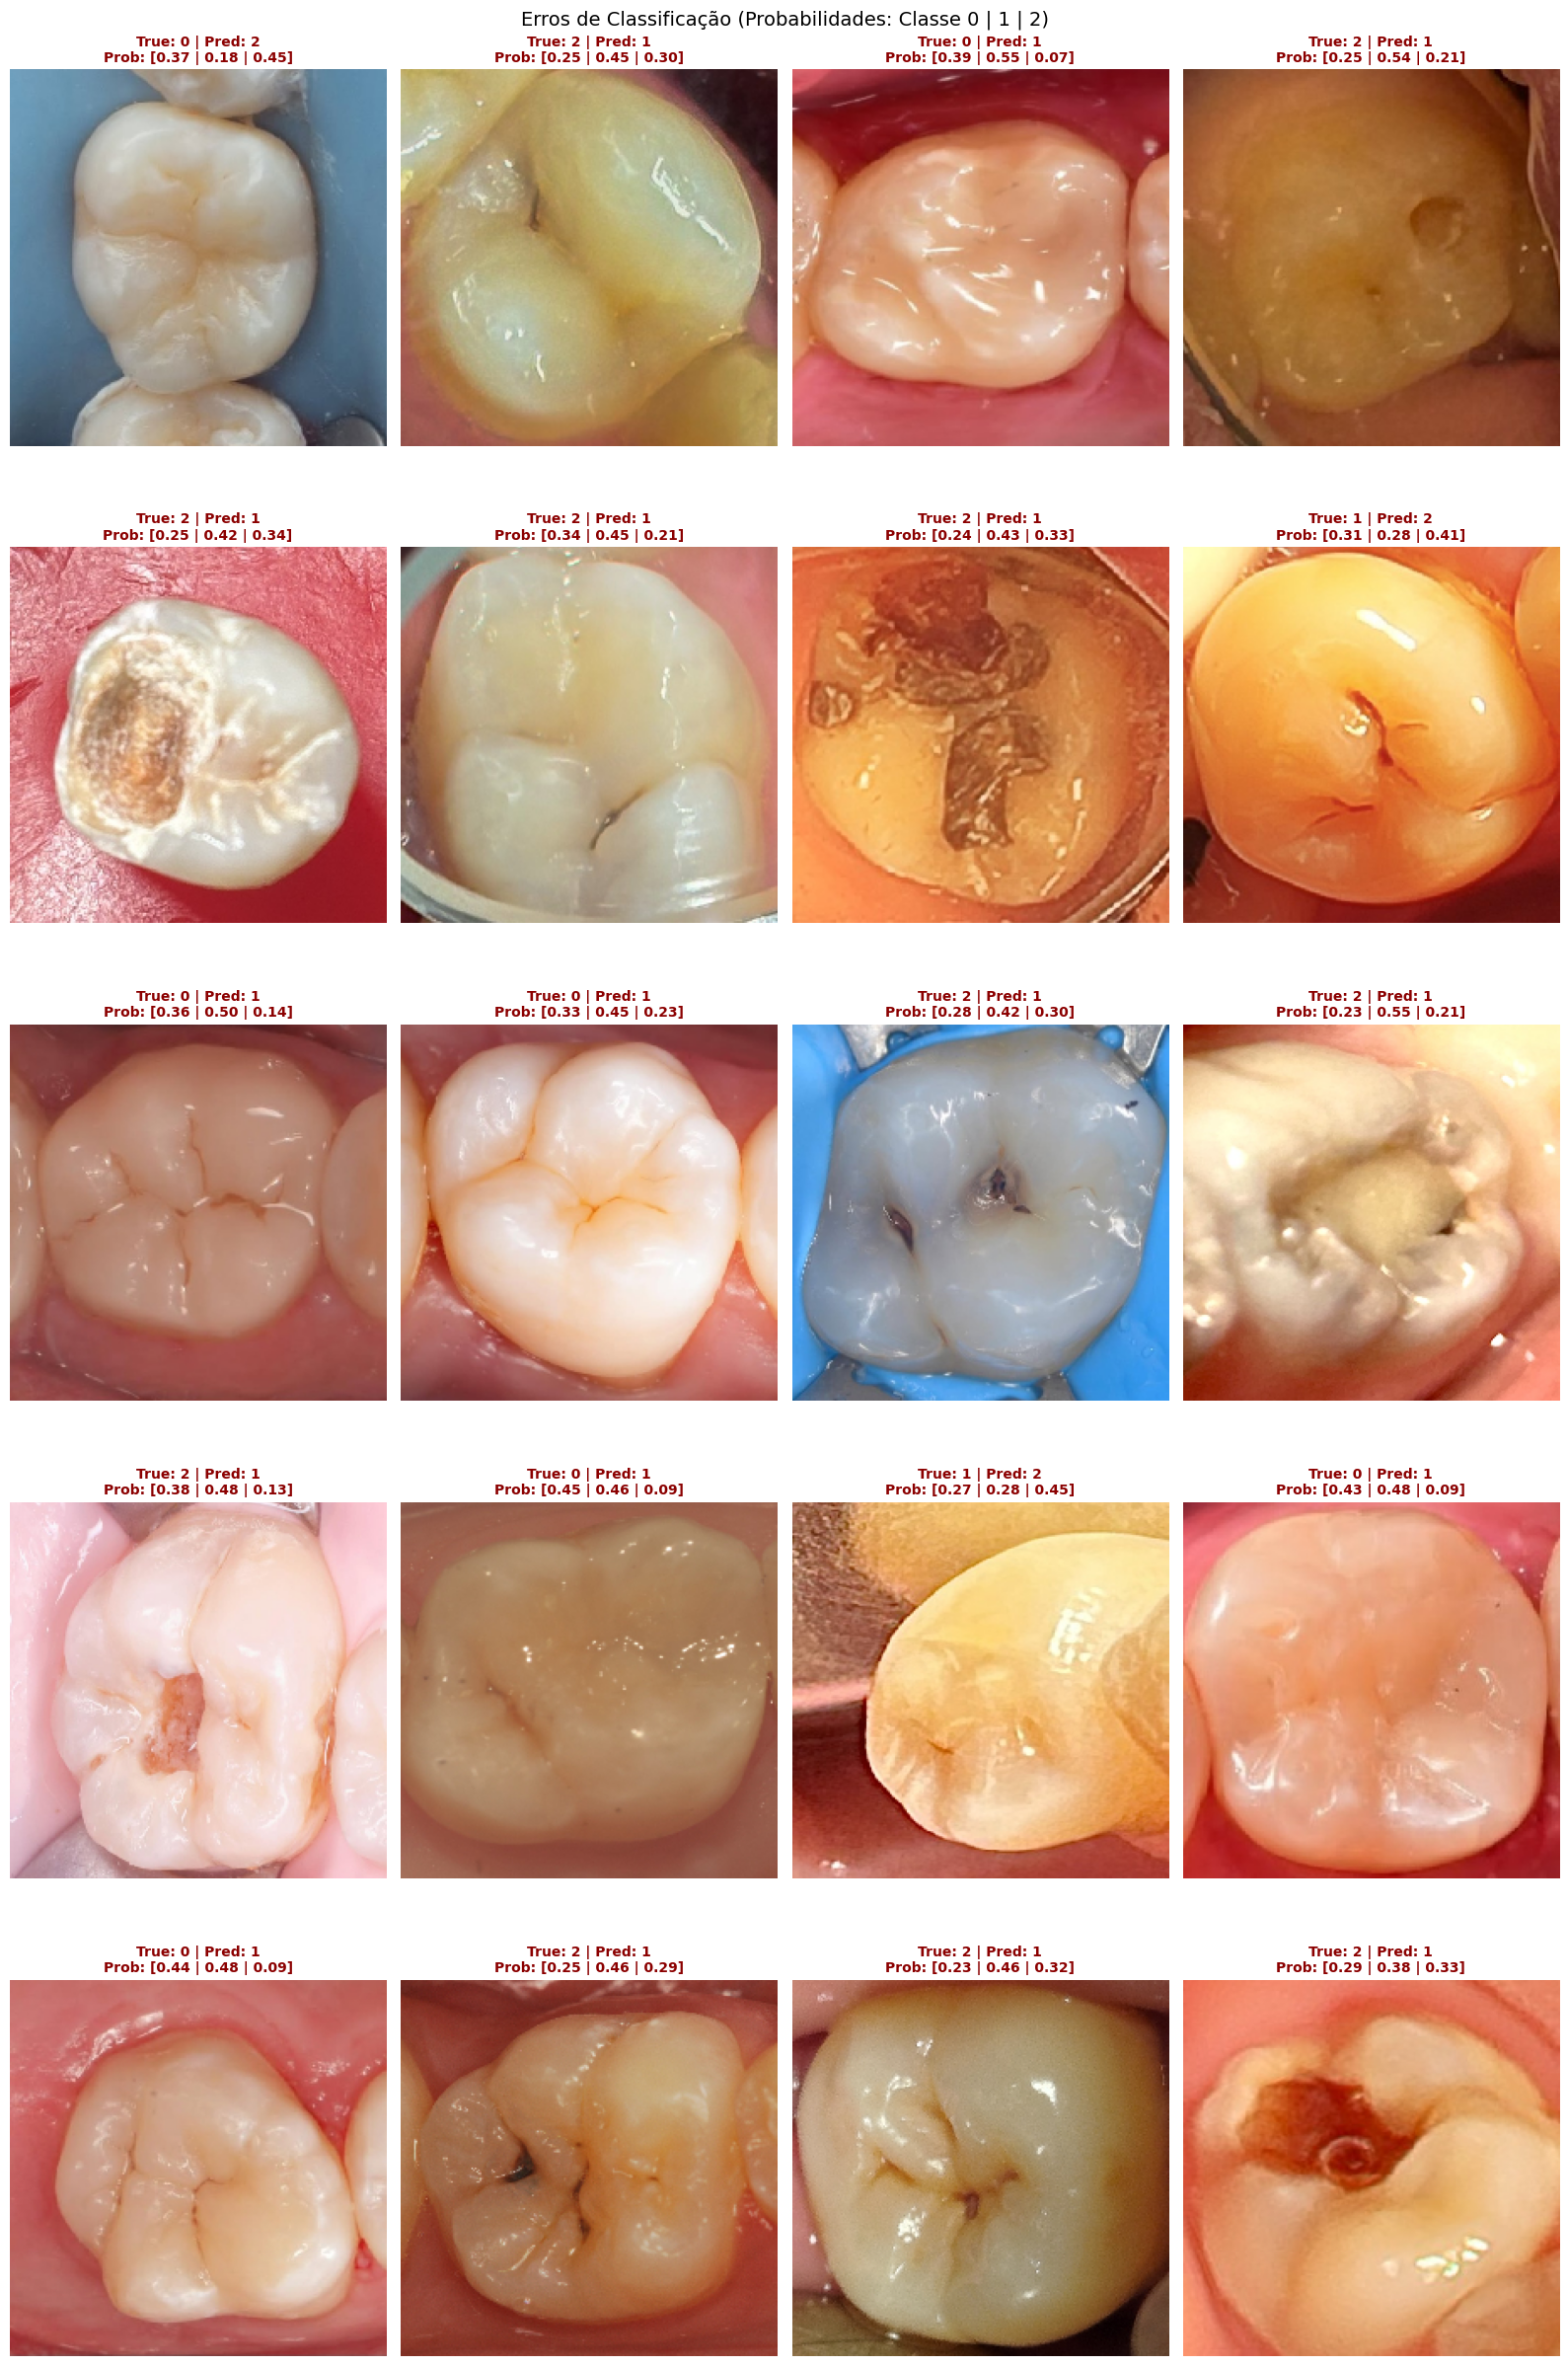

Métricas salvas em: /mnt/c/Users/laris/Documents/EngineLab/Caries/Metricas/ResNet50V2_metrics.csv


: 

In [ ]:
import itertools
from math import ceil

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Reduz logs do TensorFlow
os.environ['CUDA_VISIBLE_DEVICES'] = '0'   # Força usar apenas 1 GPU

n_repeats = 10
modelos_ids = [0,1,2,3,4,5,6,7,8,9]  # IDs de todos os extratores
base_path = DATASET_DIR
path_metrics = METRICS_DIR
classes = ['Hígidos', 'Iniciais', 'Severas']
all_logs = []

for modelo_id in modelos_ids:
    print(f"\n\n================ EXTRATOR: {modelo_id} ==================")
    for repeat in range(n_repeats):
        extractor = EXTRACTOR_NAMES[modelo_id]
        if todos_classificadores_processados(extractor, repeat, path_metrics):
          print(f"Todos os classificadores já foram processados para {extractor} | repetição {repeat}. Pulando...\n")
          continue

        print(f"\n============ Rodada {repeat+1} - Extrator {modelo_id} ============")

        # Caminhos das features salvas
        unique_id_train = f"train_r{repeat}_{extractor}"
        path_features_train = os.path.join(
            FEATURES_DIR,
            f'{unique_id_train}_features.npy'
        )
        path_labels_train = os.path.join(
            FEATURES_DIR,
            f'{unique_id_train}_labels.npy'
        )

        # PRIMEIRO: Sempre remover diretórios antigos de augmentação
        print("Limpando augmentações anteriores...")
        for class_name in classes:
            dir_path = os.path.join(DATASET_DIR, class_name, f'data_aug_rep{repeat}')
            if os.path.exists(dir_path):
                print(f"  Removendo: {dir_path}")
                shutil.rmtree(dir_path)

        # Depois verificar se as features existem
        if os.path.exists(path_features_train) and os.path.exists(path_labels_train):
            print(f"\nFeatures de treino já existem para {extractor} - repetição {repeat}. Pulando data augmentation.")

            # 1. Carregar features de TREINO (X=None pois já está no disco)
            features_train, model, extractor_name, Y_train, time_per_image = extract_features(
                model=modelo_id, X=None, y=None,
                isExtractorOnly=True, file_prefix=f'train_r{repeat}'
            )

            # 2. Carregar features de VALIDAÇÃO (X=None para evitar o erro NameError)
            features_val, _, _, Y_val, time_per_image = extract_features(
                model=modelo_id, X=None, y=None,
                isExtractorOnly=True, file_prefix=f'val_r{repeat}'
            )

            # 3. Carregar features de TESTE
            features_test, _, _, Y_test, time_per_image = extract_features(
                model=modelo_id, X=None, y=None,
                isExtractorOnly=True, file_prefix=f'test_r{repeat}'
            )

            # 4. Carregar os caminhos das imagens (necessário para o log de erros)
            path_test_raw = os.path.join(
                FEATURES_DIR,
                f'test_paths_{extractor_name}_r{repeat}.npy'
            )
            X_test_raw = np.load(path_test_raw, allow_pickle=True)

        else:
            print(f"\nRealizando novo split e data augmentation...")

            # Carrega todas as imagens puras
            all_images, all_labels = load_original_images(base_path, classes)

            print(f"\nDistribuição das imagens originais (calculada):")
            for class_idx, class_name in enumerate(classes):
                if isinstance(all_labels, list):
                    count = sum(1 for label in all_labels if label == class_idx)
                else:
                    count = 0

                print(f"Classe [{class_idx}] - {class_name} - Total de imagens: {count}")
            print(f"Total de imagens carregadas: {len(all_images)}")

            # 1. Divide em treino (80%) e teste (20%) - split estratificado
            X_temp, X_test, y_temp, y_test = train_test_split(
                  all_images, all_labels, test_size=0.2, stratify=all_labels, random_state=42 + repeat
            )

            X_train, X_val, y_train, y_val = train_test_split( # treino e validação
                X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42 + repeat
            )

            print(f"\nDivisão inicial:")
            print(f"Treino (para augmentação): {len(X_train)} imagens")
            print(f"Validação (sem augmentação): {len(X_val)} imagens")
            print(f"Teste: {len(X_test)} imagens")

            X_train_paths = X_train.copy()  # guardando caminhos de arquivo
            X_val_paths = X_val.copy()      # guardando caminhos de arquivo
            X_test_paths = X_test.copy()    # guardando caminhos de arquivo

            # 2. Aplicar augmentação só nas classes minoritárias
            # Estratégia simples: augmentação fixa por classe
            X_train_aug = []
            train_labels_aug = []

            unique, counts = np.unique(y_train, return_counts=True)
            class_counts = dict(zip(unique, counts))

            print(f"\nDistribuição no treino (antes): {class_counts}")

            max_count = max(class_counts.values())

            balance_target = max_count
            diversity_target = int(max_count * 2.9)  # Meta de diversidade: 2.9x a classe majoritária

            random.seed(42 + repeat)
            np.random.seed(42 + repeat)

            print(f"Balance target: {balance_target}")
            print(f"Diversity target: {diversity_target}")

            for cls, n_orig in class_counts.items():
                cls_paths = [p for p, y in zip(X_train, y_train) if y == cls]

                # sempre gera, até a classe maioritária
                n_needed = max(0, diversity_target - n_orig)

                print(
                    f"\nClasse {cls} ({classes[cls]}): "
                    f"{n_orig} -> +{n_needed}"
                )

                if n_needed == 0:
                    continue

                aug_per_image = int(ceil(n_needed / n_orig))

                generated = []

                for img_path in itertools.cycle(cls_paths):
                    if len(generated) >= n_needed:
                        break

                    try:
                        aug_dir = os.path.join(
                            os.path.dirname(img_path),
                            f'data_aug_rep{repeat}'
                        )
                        os.makedirs(aug_dir, exist_ok=True)

                        original_name = os.path.splitext(os.path.basename(img_path))[0]
                        img = Image.open(img_path).convert('RGB')

                        augmented_imgs = apply_manual_augmentations(
                            img,
                            num_aug=aug_per_image
                        )

                        for aug_img in augmented_imgs:
                            if len(generated) >= n_needed:
                                break

                            aug_path = os.path.join(
                                aug_dir,
                                f"{original_name}_aug_{len(generated)}.jpg"
                            )

                            aug_img.save(aug_path)
                            generated.append(aug_path)

                    except Exception as e:
                        print(f"[AVISO] {img_path}: {e}")

                X_train_aug.extend(generated)
                train_labels_aug.extend([cls] * len(generated))

                print(f"  Geradas: {len(generated)}")

            train_imgs_final = X_train + X_train_aug
            train_labels_final = np.concatenate([y_train, train_labels_aug])

            # Verificação
            print("\nResumo da augmentação:")
            for cls in np.unique(train_labels_final):
                print(f"Classe {cls} ({classes[cls]}): {np.sum(train_labels_final == cls)} imagens")

            overlap = set(train_imgs_final).intersection(set(X_test))
            print(f"\nOverlap entre treino e teste: {len(overlap)} paths (deve ser 0)")

            print(f"\nVerificação de augmentação:")
            print(f"Imagens originais no treino: {len(X_train)}")
            print(f"Imagens augmentadas geradas: {len(X_train_aug)}")
            print(f"Total final de treino: {len(train_imgs_final)}")
            print(f"Ratio augmentações/originais: {len(X_train_aug)/len(X_train):.1f}")

            # Processar imagens
            X_train_processed = process_images(train_imgs_final)
            Y_train = np.array(train_labels_final)
            X_val_processed = process_images(X_val_paths)
            Y_val = np.array(y_val)
            X_test_processed = process_images(X_test_paths)
            Y_test = np.array(y_test)

            print(f"\nDados finais:")
            print(f"Total de imagens de treino: {len(X_train_processed)}")
            print(f"Total de imagens de teste: {len(X_test_processed)}")
            print(f"Distribuição das classes no treino: {np.bincount(Y_train)}")
            print(f"Distribuição das classes no teste: {np.bincount(Y_test)}")

            X_train = X_train_processed  # Array numpy
            X_val = X_val_processed      # Array numpy
            X_test = X_test_processed    # Array numpy

            # 4. Pré-processamento para CNN
            X_train_pre = preprocessar_imagens(X_train.astype('float32'), modelo_id)
            X_val_pre = preprocessar_imagens(X_val.astype('float32'), modelo_id)
            X_test_pre = preprocessar_imagens(X_test.astype('float32'), modelo_id)

            # PARA USO POSTERIOR: manter os caminhos SEPARADOS
            X_test_raw_paths = X_test_paths.copy()  # Caminhos de arquivo
            X_val_raw_paths = X_val_paths.copy()    # Caminhos de arquivo

            # 5. Extrair features de treino, validação e teste
            # features de treino
            features_train, model, extractor_name, y_loaded, t_train, time_per_image = extract_features(
                model=modelo_id, X=X_train_pre, y=Y_train,
                isExtractorOnly=True, file_prefix=f'train_r{repeat}'
            )
            Y_train = y_loaded

            # features da validação
            features_val, _, _, _, t_val, time_per_image = extract_features(
                model=modelo_id, X=X_val_pre, y=Y_val,
                isExtractorOnly=True, file_prefix=f'val_r{repeat}'
            )

            # features de teste
            features_test, _, _, _, t_test, time_per_image = extract_features(
                model=modelo_id, X=X_test_pre, y=Y_test,
                isExtractorOnly=True, file_prefix=f'test_r{repeat}'
            )

            tempo_extracao_total = t_train + t_val + t_test

            # Salvar os paths do conjunto de teste
            path_test_raw = os.path.join(
                FEATURES_DIR,
                f'test_paths_{extractor_name}_r{repeat}.npy'
            )
            np.save(path_test_raw, X_test_raw_paths)

            print(f"\nMédia das features: {np.mean(features_train):.4f}")
            print(f"Desvio padrão: {np.std(features_train):.4f}")

        # 6. Treinamento (classificadores tradicionais)
        # SVM
        if not classificador_processado("svm", extractor, repeat, path_metrics):
          print("Treinando SVM...")
          metrics_svm, final_svm, std_svm, time_svm, logs_svm = classifiers(
              "svm", model_params, features_train, Y_train, features_val, Y_val, features_test, Y_test, list_paths_test=X_test_raw_paths, tempo_extracao_total=tempo_extracao_total, time_per_image_cnn=time_per_image
          )
          save_metrics(metrics_svm, final_svm, std_svm, time_svm, "svm", extractor_name, path_metrics, repeat=repeat)
        # print_metrics(metrics_svm, final_svm, std_svm, time_svm, nome_modelo="SVM")

        # MLP (scikit-learn)
        if not classificador_processado("mlp", extractor, repeat, path_metrics):
          print("Treinando MLP...")
          metrics_mlp, final_mlp, std_mlp, time_mlp, logs_mlp = classifiers(
              "mlp", model_params, features_train, Y_train, features_val, Y_val, features_test, Y_test, list_paths_test=X_test_raw_paths, tempo_extracao_total=tempo_extracao_total, time_per_image_cnn=time_per_image
          )
          save_metrics(metrics_mlp, final_mlp, std_mlp, time_mlp, "mlp", extractor_name, path_metrics, repeat=repeat)
        # print_metrics(metrics_mlp, final_mlp, std_mlp, time_mlp, nome_modelo="MLP - Sklearn")

        if not classificador_processado("rf", extractor, repeat, path_metrics):
          print("Treinando Random Forest...")
          metrics_rf, final_rf, std_rf, time_rf, logs_rf = classifiers(
              "rf", model_params, features_train, Y_train, features_val, Y_val, features_test, Y_test, list_paths_test=X_test_raw_paths, tempo_extracao_total=tempo_extracao_total, time_per_image_cnn=time_per_image
          )
          save_metrics(
              metrics_rf, final_rf, std_rf, time_rf, "rf", extractor_name, path_metrics, repeat=repeat
          )

        # Pipeline 2: CNN pura (end-to-end) ------------------
        if not classificador_processado("cnn", extractor, repeat, path_metrics):
            cnn_metrics, cnn_final_metrics, cnn_stds, cnn_times, logs_cnn = cnn_classifier(
                model_id=modelo_id,
                X_train=X_train_pre, # IMAGENS, NÃO FEATURES!
                Y_train=Y_train,
                X_val=X_val_pre,     # IMAGENS
                Y_val=Y_val,
                X_test=X_test_pre,   # IMAGENS
                Y_test=Y_test,
                n_classes=len(np.unique(Y_train)),
                list_paths_test=X_test_raw_paths,  # Caminhos para erros
                repeat=repeat,
                tempo_extracao_total=tempo_extracao_total,
                time_per_image_cnn=time_per_image
            )

            save_metrics(
                cnn_metrics,
                cnn_final_metrics,
                cnn_stds,
                cnn_times,
                "cnn",
                extractor_name,
                path_metrics,
                repeat=repeat
            )

            #all_logs.extend(logs_knn['val_predictions'])
            #all_logs.extend(logs_knn['test_predictions'])
            #all_logs.extend(logs_svm['val_predictions'])
            #all_logs.extend(logs_svm['test_predictions'])
            #all_logs.extend(logs_mlp['val_predictions'])
            #all_logs.extend(logs_mlp['test_predictions'])
            #all_logs.extend(logs_rf['val_predictions'])
            #all_logs.extend(logs_rf['test_predictions'])
            #all_logs.extend(logs_cnn['val_predictions'])
            #all_logs.extend(logs_cnn['test_predictions'])

In [ ]:
# path_metrics = '/content/drive/MyDrive/Pesquisa/Dentes/Metrics csv/'
# calcular_medias_csv(path_metrics)

# Testes Estatísticos

## Teste de Friedman

In [ ]:
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

# ==========================================
# CONFIGURAÇÕES
# ==========================================
path_metrics = METRICS_DIR
METRICA_ALVO = "Kappa Quadrático (QWK)"
ALPHA_GLOBAL = 0.05
ALPHA_POSTHOC = 0.05 / 6

# ==========================================
# 1. CARREGAR TODOS OS MODELOS AUTOMATICAMENTE
# ==========================================
dados_modelos = {}
num_reps = None

for arquivo in os.listdir(path_metrics):
    if arquivo.endswith("_metrics.csv"):
        caminho = os.path.join(path_metrics, arquivo)
        cnn_name = arquivo.replace("_metrics.csv", "")

        df = pd.read_csv(caminho)

        for modelo in df["Modelo"].unique():
            df_modelo = df[df["Modelo"] == modelo].sort_values("Repetição")

            vetor = df_modelo[METRICA_ALVO].values

            nome_completo = f"{cnn_name}+{modelo}"
            dados_modelos[nome_completo] = vetor

            if num_reps is None:
                num_reps = len(vetor)
            if len(vetor) != num_reps:
                raise ValueError(f"Inconsistência no número de repetições em {nome_completo}")

print(f"{len(dados_modelos)} modelos carregados.")
print(f"{num_reps} repetições por modelo.")

# ==========================================
# 2. ORGANIZAR MATRIZ PARA FRIEDMAN
# ==========================================
matriz = np.column_stack(list(dados_modelos.values()))

# ==========================================
# 3. TESTE GLOBAL DE FRIEDMAN
# ==========================================
stat_f, p_friedman = friedmanchisquare(*[matriz[:, i] for i in range(matriz.shape[1])])

print("\n=================================================")
print("FRIEDMAN GLOBAL (todos os modelos)")
print("=================================================")
print(f"p-valor: {p_friedman:.6f}")

if p_friedman < ALPHA_GLOBAL:
    print("-> Diferença global significativa detectada.")
else:
    print("-> Nenhuma diferença global significativa.")

40 modelos carregados.
20 repetições por modelo.

FRIEDMAN GLOBAL (todos os modelos)
p-valor: 0.000000
-> Diferença global significativa detectada.


## Teste de Wilcoxon

In [ ]:
print("\n=================================================")
print("Willcoxon: Comparação entre classificadores dentro de cada CNN")
print("=================================================")

for arquivo in os.listdir(path_metrics):
    if arquivo.endswith("_metrics.csv"):
        caminho = os.path.join(path_metrics, arquivo)
        cnn_name = arquivo.replace("_metrics.csv", "")

        df = pd.read_csv(caminho)

        modelos = df["Modelo"].unique()
        print(f"\n--- {cnn_name} ---")

        for m1, m2 in combinations(modelos, 2):
            v1 = df[df["Modelo"] == m1].sort_values("Repetição")[METRICA_ALVO].values
            v2 = df[df["Modelo"] == m2].sort_values("Repetição")[METRICA_ALVO].values

            stat, p = wilcoxon(v1, v2, alternative='two-sided')

            print(f"{m1} vs {m2} -> p = {p:.5f} -> "
                f"{'SIGNIFICATIVO' if p < ALPHA_POSTHOC else 'NS'}")


PÓS-HOC: Comparação entre classificadores dentro de cada CNN

--- ConvNeXtSmall ---
svm vs mlp -> p = 0.04844 -> NS
svm vs rf -> p = 0.00005 -> SIGNIFICATIVO
svm vs cnn -> p = 0.67422 -> NS
mlp vs rf -> p = 0.00026 -> SIGNIFICATIVO
mlp vs cnn -> p = 0.06372 -> NS
rf vs cnn -> p = 0.00013 -> SIGNIFICATIVO

--- EfficientNetV2B0 ---
svm vs mlp -> p = 0.49801 -> NS
svm vs rf -> p = 0.00000 -> SIGNIFICATIVO
svm vs cnn -> p = 0.00001 -> SIGNIFICATIVO
mlp vs rf -> p = 0.00000 -> SIGNIFICATIVO
mlp vs cnn -> p = 0.00002 -> SIGNIFICATIVO
rf vs cnn -> p = 0.32998 -> NS

--- EfficientNetV2B3 ---
svm vs mlp -> p = 0.86949 -> NS
svm vs rf -> p = 0.00000 -> SIGNIFICATIVO
svm vs cnn -> p = 0.00001 -> SIGNIFICATIVO
mlp vs rf -> p = 0.00000 -> SIGNIFICATIVO
mlp vs cnn -> p = 0.00000 -> SIGNIFICATIVO
rf vs cnn -> p = 0.02395 -> NS

--- InceptionResNetV2 ---
svm vs mlp -> p = 0.60087 -> NS
svm vs rf -> p = 0.00000 -> SIGNIFICATIVO
svm vs cnn -> p = 0.00199 -> SIGNIFICATIVO
mlp vs rf -> p = 0.00000 -> SIG

## Intervalo de Confiança (95%)

In [ ]:
from sklearn.utils import resample
import glob

# CONFIGURAÇÕES
path_metrics = METRICS_DIR
METRICA_ALVO = "Precisão Macro Teste (%)"
N_BOOT = 10000
IC = 95

def bootstrap_ic(valores, n_boot=10000, ic=95):
    medias = []
    for _ in range(n_boot):
        amostra = resample(valores, replace=True)
        medias.append(np.mean(amostra))
    lower = np.percentile(medias, (100 - ic) / 2)
    upper = np.percentile(medias, 100 - (100 - ic) / 2)
    return lower, upper

# Encontra todos os arquivos de métricas na pasta
arquivos_csv = glob.glob(os.path.join(path_metrics, "*_metrics.csv"))

resultados_finais = []

for arquivo in arquivos_csv:
    # Extrai o nome da CNN a partir do nome do arquivo (ex: VGG16_metrics.csv -> VGG16)
    nome_cnn = os.path.basename(arquivo).replace("_metrics.csv", "")

    df = pd.read_csv(arquivo)

    # Pega todos os classificadores únicos presentes no arquivo (svm, mlp, rf, cnn)
    classificadores = df["Modelo"].unique()

    for modelo in classificadores:
        # Filtra os 20 valores da combinação atual
        valores = df[df["Modelo"] == modelo][METRICA_ALVO].values

        # Garante que existem valores para não dar erro
        if len(valores) > 0:
            media = np.mean(valores)
            lower, upper = bootstrap_ic(valores, N_BOOT, IC)

            # Formatação para artigos: "0.84 (0.81 - 0.86)"
            texto_artigo = f"{media:.2f} ({lower:.2f} - {upper:.2f})"

            resultados_finais.append({
                "CNN": nome_cnn,
                "Classificador": modelo.upper(),
                "Precisão Média": round(media, 4),
                "IC_Lower": round(lower, 4),
                "IC_Upper": round(upper, 4),
                "Formato_Artigo": texto_artigo
            })

# Verifica se a lista de resultados não está vazia antes de criar o DataFrame
if len(resultados_finais) == 0:
    print("ERRO: Nenhum dado foi processado!")
    print(f"Verifique se o caminho da pasta está correto: {path_metrics}")
    print("Verifique também se os arquivos na pasta terminam exatamente com '_metrics.csv'.")
else:
    # Cria o DataFrame final e ordena
    df_resultados = pd.DataFrame(resultados_finais)
    df_resultados = df_resultados.sort_values(by="Precisão Média", ascending=False).reset_index(drop=True)

    print("\nCálculo concluído! Primeiros resultados:")
    print(df_resultados.head(10))

    # Salva o arquivo final
    df_resultados.to_csv("tabela_ic95_precisao_todos_modelos.csv", index=False)
    print("\nArquivo 'tabela_ic95_precisao_todos_modelos.csv' salvo com sucesso!")

print("Cálculo concluído! Primeiros resultados:")
print(df_resultados.head(10))

# Salva tudo em um único arquivo pronto para análise ou conversão pro LaTeX
df_resultados.to_csv("tabela_ic95_precisao_todos_modelos.csv", index=False)


Cálculo concluído! Primeiros resultados:
                CNN Classificador  Precisão Média  IC_Lower  IC_Upper  \
0  EfficientNetV2B3           SVM         83.4125   81.1402   85.6445   
1             VGG19           CNN         82.4260   80.2196   84.6565   
2  EfficientNetV2B3           MLP         82.3957   80.0929   84.7076   
3        ResNet50V2           SVM         82.1001   80.4304   83.8800   
4  MobileNetV3Small           MLP         81.6724   79.2254   83.8879   
5  EfficientNetV2B0           SVM         81.2443   78.8577   83.7063   
6  MobileNetV3Small           SVM         81.0441   78.5339   83.3697   
7  EfficientNetV2B0           MLP         80.7738   78.8781   82.6684   
8             VGG16           CNN         80.1908   78.0351   82.3397   
9          ResNet50           SVM         80.1905   78.5180   81.8961   

          Formato_Artigo  
0  83.41 (81.14 - 85.64)  
1  82.43 (80.22 - 84.66)  
2  82.40 (80.09 - 84.71)  
3  82.10 (80.43 - 83.88)  
4  81.67 (79.23 - 8

In [ ]:

from scipy.stats import wilcoxon

# ===============================
# CONFIGURAÇÕES
# ===============================
path_metrics = METRICS_DIR
METRICA_ALVO = "Kappa Quadrático (QWK)"

TOP10_MODELOS = [
    ("EfficientNetV2B3", "svm"),
    ("EfficientNetV2B3", "mlp"),
    ("ResNet50V2", "svm"),
    ("MobileNetV3Small", "mlp"),
    ("MobileNetV3Small", "svm"),
    ("EfficientNetV2B0", "svm"),
    ("ResNet50", "cnn"),
    ("EfficientNetV2B0", "mlp"),
    ("ResNet50", "svm"),
    ("EfficientNetV2B3", "cnn"),
]

# ===============================
# 1️Carregar resultados
# ===============================
resultados = {}

for cnn, modelo in TOP10_MODELOS:
    arquivo = os.path.join(path_metrics, f"{cnn}_metrics.csv")
    df = pd.read_csv(arquivo)

    valores = (
        df[df["Modelo"] == modelo]
        .sort_values("Repetição")[METRICA_ALVO]
        .values
    )

    resultados[(cnn, modelo)] = valores

# ===============================
# 2️⃣ Wilcoxon Top1 vs demais
# ===============================
top1 = TOP10_MODELOS[0]
valores_top1 = resultados[top1]

alpha = 0.05
n_comparacoes = len(TOP10_MODELOS) - 1
alpha_corrigido = alpha / n_comparacoes

print("\n==========================================")
print("Wilcoxon — Top1 vs Top9")
print("==========================================")
print(f"Alpha corrigido (Bonferroni): {alpha_corrigido:.5f}\n")

for modelo in TOP10_MODELOS[1:]:
    valores_modelo = resultados[modelo]

    stat, p = wilcoxon(valores_top1, valores_modelo)

    print(f"{top1} vs {modelo}")
    print(f"p-valor: {p:.6f}")
    print(f"Significativo? {p < alpha_corrigido}")
    print("-" * 40)


Wilcoxon — Top1 vs Top9
Alpha corrigido (Bonferroni): 0.00556

('EfficientNetV2B3', 'svm') vs ('EfficientNetV2B3', 'mlp')
p-valor: 0.869488
Significativo? False
----------------------------------------
('EfficientNetV2B3', 'svm') vs ('ResNet50V2', 'svm')
p-valor: 0.368277
Significativo? False
----------------------------------------
('EfficientNetV2B3', 'svm') vs ('MobileNetV3Small', 'mlp')
p-valor: 0.452375
Significativo? False
----------------------------------------
('EfficientNetV2B3', 'svm') vs ('MobileNetV3Small', 'svm')
p-valor: 0.294252
Significativo? False
----------------------------------------
('EfficientNetV2B3', 'svm') vs ('EfficientNetV2B0', 'svm')
p-valor: 0.474905
Significativo? False
----------------------------------------
('EfficientNetV2B3', 'svm') vs ('ResNet50', 'cnn')
p-valor: 0.032768
Significativo? False
----------------------------------------
('EfficientNetV2B3', 'svm') vs ('EfficientNetV2B0', 'mlp')
p-valor: 0.142906
Significativo? False
------------------

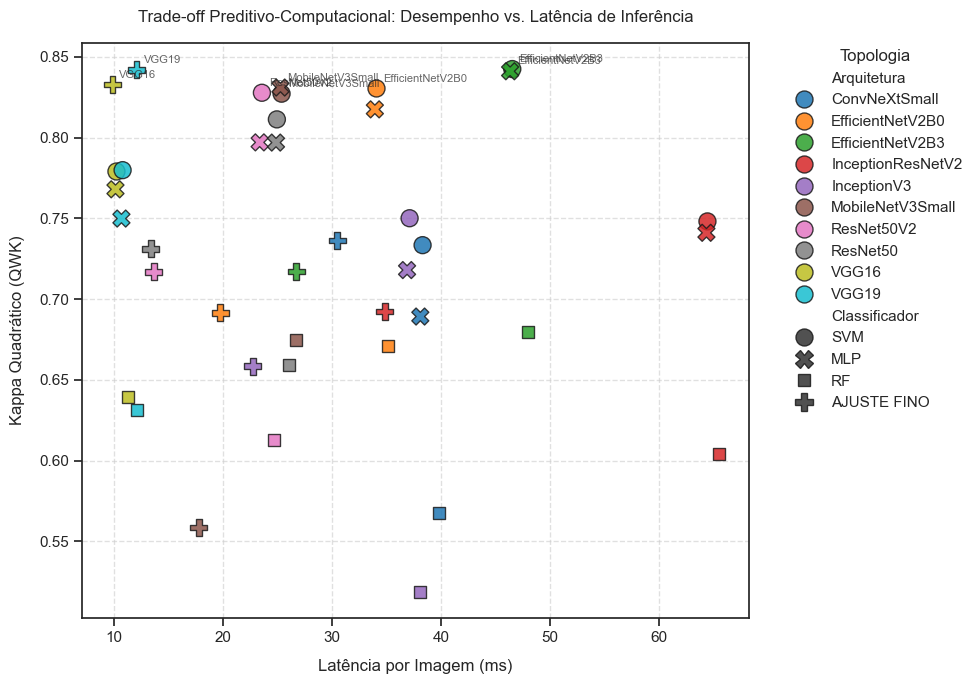

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo para artigos científicos
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# 1. Coletar os dados de todos os arquivos
dados_finais = []
diretorio = METRICS_DIR # Mude para o caminho da sua pasta se necessário

for arquivo in os.listdir(diretorio):
    if arquivo.endswith("_medias.csv"):
        arquitetura = arquivo.replace("_medias.csv", "")
        caminho = os.path.join(diretorio, arquivo)

        df = pd.read_csv(caminho)

        # Filtrar apenas as linhas onde a Repetição é a 'MÉDIA' (ou ler direto o modelo)
        # Assumindo que a coluna 'Modelo' tem 'svm', 'mlp', 'rf', 'cnn'
        for _, row in df.iterrows():
            modelo_classificador = str(row['Modelo']).upper()
            if modelo_classificador == 'CNN':
                modelo_classificador = 'AJUSTE FINO' # Renomear para o gráfico ficar mais claro

            qwk = float(row['Kappa Quadrático (QWK)'])
            latencia = float(row['Latência por Imagem (ms)'])

            dados_finais.append({
                'Arquitetura': arquitetura,
                'Classificador': modelo_classificador,
                'QWK': qwk,
                'Latência (ms)': latencia
            })

df_plot = pd.DataFrame(dados_finais)

# 2. Criar a Figura
plt.figure(figsize=(10, 7))
sns.set_theme(style="ticks") # Estilo limpo de artigo

# Paleta de cores para diferenciar bem as 10 CNNs
paleta = sns.color_palette("tab10", n_colors=len(df_plot['Arquitetura'].unique()))

# 3. Plotar o Gráfico de Dispersão
grafico = sns.scatterplot(
    data=df_plot,
    x="Latência (ms)",
    y="QWK",
    hue="Arquitetura",
    style="Classificador",
    s=150,           # Tamanho dos pontos
    palette=paleta,
    alpha=0.85,      # Leve transparência para pontos sobrepostos
    edgecolor="k"    # Borda preta nos pontos
)

# 4. Ajustes estéticos para artigo A1
plt.title("Trade-off Preditivo-Computacional: Desempenho vs. Latência de Inferência", pad=15)
plt.xlabel("Latência por Imagem (ms)", labelpad=10)
plt.ylabel("Kappa Quadrático (QWK)", labelpad=10)

# Grid pontilhado sutil
plt.grid(True, linestyle='--', alpha=0.6)

# Mover a legenda para fora do gráfico para não cobrir os dados
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Topologia", frameon=False)

# 5. Destacar os melhores modelos (Fronteira de Pareto - Canto superior esquerdo)
# Vamos circular os pontos com melhor balanço (ajuste os nomes conforme seus dados)
melhores = df_plot[df_plot['QWK'] > 0.82]
for _, row in melhores.iterrows():
    plt.annotate(
        row['Arquitetura'],
        (row['Latência (ms)'], row['QWK']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=8, alpha=0.7
    )

plt.tight_layout()

# Salvar em alta resolução (300 dpi é exigência de periódicos)
plt.savefig("grafico_tradeoff_latencia.png", dpi=300, bbox_inches='tight')
plt.savefig("grafico_tradeoff_latencia.pdf", bbox_inches='tight') # Formato vetorial excelente para LaTeX
plt.show()

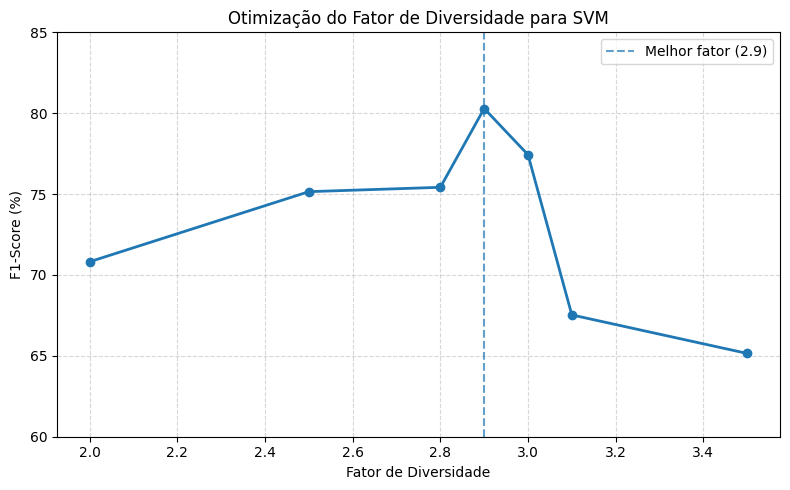

In [ ]:
import matplotlib.pyplot as plt

x = [2.0, 2.5, 2.8, 2.9, 3.0, 3.1, 3.5]
y = [70.82, 75.15, 75.42, 80.29, 77.43, 67.53, 65.15]

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', linewidth=2)

plt.axvline(x=2.9, linestyle='--', alpha=0.7,
            label='Melhor fator (2.9)')

plt.xlabel('Fator de Diversidade')
plt.ylabel('F1-Score (%)')
plt.title('Otimização do Fator de Diversidade para SVM')
plt.ylim(60, 85)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

Lendo os dados e rastreando o Ajuste Fino...

Sucesso: Ajuste Fino Parcial na ConvNeXtSmall registrado com 30.5 ms
Sucesso: Ajuste Fino Parcial na EfficientNetV2B0 registrado com 19.8 ms
Sucesso: Ajuste Fino Parcial na EfficientNetV2B3 registrado com 26.7 ms
Sucesso: Ajuste Fino Parcial na InceptionResNetV2 registrado com 34.9 ms
Sucesso: Ajuste Fino Parcial na InceptionV3 registrado com 22.8 ms
Sucesso: Ajuste Fino Parcial na MobileNetV3Small registrado com 17.8 ms
Sucesso: Ajuste Fino Parcial na ResNet50V2 registrado com 13.7 ms
Sucesso: Ajuste Fino Parcial na ResNet50 registrado com 13.4 ms
Sucesso: Ajuste Fino Parcial na VGG16 registrado com 9.9 ms
Sucesso: Ajuste Fino Parcial na VGG19 registrado com 12.1 ms
Empty DataFrame
Columns: [Arquitetura, Classificador, Latência (ms)]
Index: []

Gráfico gerado com sucesso! Verifique a imagem salva.


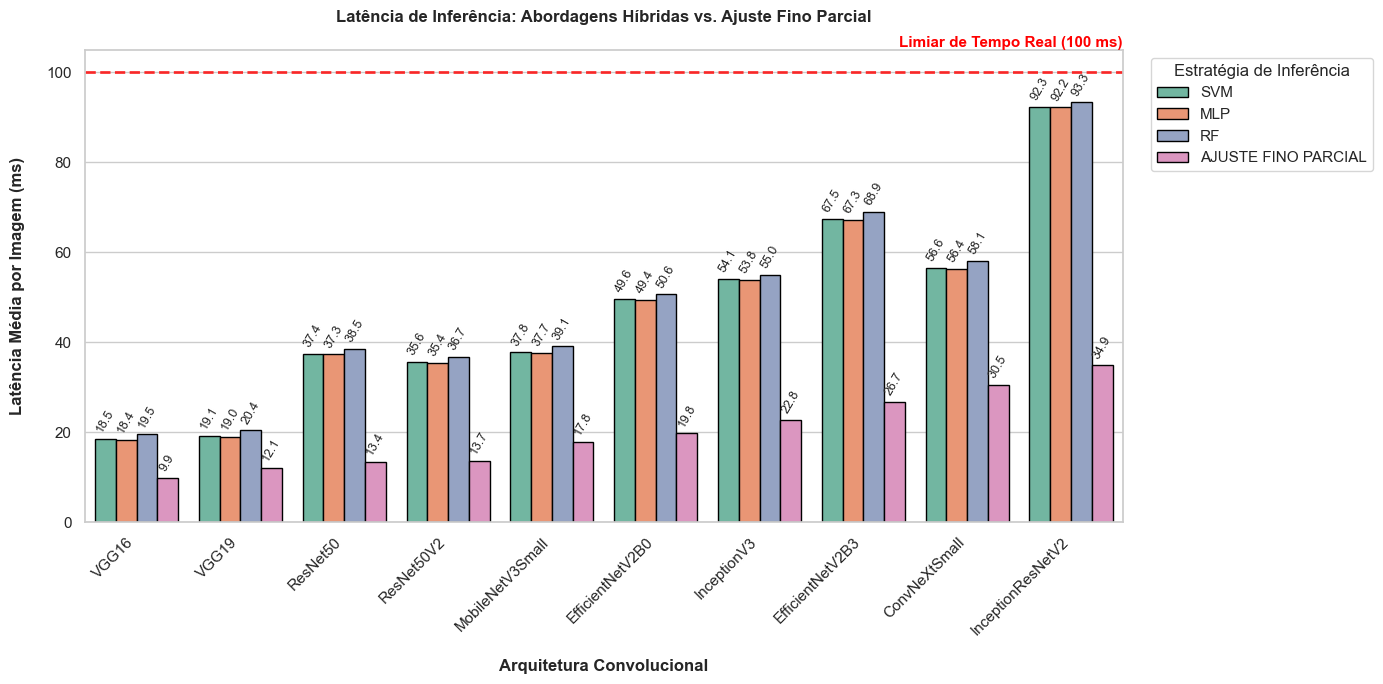

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo para artigos científicos
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

dados_finais = []
diretorio = METRICS_DIR # Diretório atual onde estão os arquivos _medias.csv

print("Lendo os dados e rastreando o Ajuste Fino...\n")

for arquivo in os.listdir(diretorio):
    if arquivo.endswith("_medias.csv"):
        arquitetura = arquivo.replace("_medias.csv", "")
        caminho = os.path.join(diretorio, arquivo)

        df = pd.read_csv(caminho)

        # Procura a coluna com a conta certa
        coluna_tempo = "Latência Real (ms)"
        if coluna_tempo not in df.columns:
            coluna_tempo = "Latência por Imagem (ms)"

        for _, row in df.iterrows():
            # 1. FILTRO DE SEGURANÇA: Garantir que só estamos lendo as linhas finais de MÉDIA
            repeticao = str(row.get('Repetição', '')).strip().upper()
            if repeticao != 'MÉDIA':
                continue

            # 2. LIMPEZA DE STRING: Remove espaços invisíveis do nome do modelo
            modelo_classificador = str(row.get('Modelo', '')).strip().upper()

            if modelo_classificador == 'CNN':
                modelo_classificador = 'AJUSTE FINO PARCIAL' # Renomear para o gráfico ficar mais claro

            try:
                latencia = float(row[coluna_tempo])

                # 3. PLANO B: Se a latência calculada deu NaN (Nula) por causa de células vazias
                if pd.isna(latencia):
                    latencia = (float(row['Tempo de Teste (s)']) / 72) * 1000
            except:
                continue # Pula se houver erro grave na linha

            if modelo_classificador == 'AJUSTE FINO PARCIAL':
                print(f"Sucesso: Ajuste Fino Parcial na {arquitetura} registrado com {latencia:.1f} ms")

            dados_finais.append({
                'Arquitetura': arquitetura,
                'Classificador': modelo_classificador,
                'Latência (ms)': latencia
            })

df_plot = pd.DataFrame(dados_finais)
print(df_plot[df_plot['Latência (ms)'] <= 1])

# Ordenar as arquiteturas da mais rápida para a mais lenta
ordem_arquiteturas = (
    df_plot.groupby('Arquitetura')['Latência (ms)']
    .min()
    .sort_values()
    .index
)

# Criar a Figura
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Paleta de cores para os 4 classificadores
paleta_classificadores = sns.color_palette("Set2", n_colors=4)

# Plotar o Gráfico de Barras Agrupadas
grafico = sns.barplot(
    data=df_plot,
    x="Arquitetura",
    y="Latência (ms)",
    hue="Classificador",
    order=ordem_arquiteturas,
    palette=paleta_classificadores,
    edgecolor="black",
    linewidth=1,
    capsize=0.05
)

for p in grafico.patches:
    altura = p.get_height()

    if not pd.isna(altura) and altura > 1:  # ignora zeros
        grafico.annotate(
            f'{altura:.1f}',
            (p.get_x() + p.get_width() / 2., altura),
            ha='center',
            va='bottom',
            fontsize=9,
            rotation=60,
            xytext=(0, 3),
            textcoords='offset points'
        )

# Ajustes estéticos para o padrão A1/Q1
plt.title("Latência de Inferência: Abordagens Híbridas vs. Ajuste Fino Parcial", pad=20, fontweight='bold')
plt.xlabel("Arquitetura Convolucional", labelpad=15, fontweight='bold')
plt.ylabel("Latência Média por Imagem (ms)", labelpad=15, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Estratégia de Inferência", frameon=True)

# LINHA DE CORTE DO TEMPO REAL
plt.axhline(y=100, color='red', linestyle='--', linewidth=2, alpha=0.8)
plt.text(len(ordem_arquiteturas)-0.5, 105, 'Limiar de Tempo Real (100 ms)', color='red', ha='right', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()

plt.savefig("grafico_latencia_final.png", dpi=300, bbox_inches='tight')
plt.savefig("grafico_latencia_final.pdf", bbox_inches='tight')

print("\nGráfico gerado com sucesso! Verifique a imagem salva.")
plt.show()